# Avaliação de Modelos

**Projeto:** Projeto ANEEL - Energia em Risco: Análise de Dados de Continuidade Elétrica e Previsão de Risco Regulatório

**Metodologia:** CRISP-DM

**Período de Análise:** 2021 – 2025

---

## Visão Geral

Este notebook consolida a **Fase 5 do CRISP-DM - Avaliação (Evaluation)** com a avaliação das métricas no conjunto de teste, comparação com baseline, avaliação do limiar operacional, comparativo de estabilidade e generalização temporal, análise de erros e resíduos, features mais determinantes, distribuição dos scores de risco e limitações do modelo.

---

## Sumário

- **1.** Configurações do ambiente
- **2.** Carregamento das bases, modelo e metadados
- **3.** Avaliação no conjunto de teste
- **4.** Comparação com baseline
- **5.** Análise do limiar operacional
- **6.** Estabilidade e generalização temporal
- **7.** Análise dos erros
    - **7.1.** Auditoria de falsos negativos
    - **7.2.** Limiar operacional, recall e falsos positivos
- **8.** Análise dos resíduos
- **9.** Importância e pesos dos atributos
- **10.** Distribuição de scores de risco
    - **10.1.** Distribuição dos scores por classe real
    - **10.2.** Distribuição do score por faixa operacional
- **11.** Limitações do modelo
- **12.** Conclusões da avaliação

---


## 1. Configurações do ambiente

In [10]:
# Importações e configurações do ambiente
import os
import sys
from pathlib import Path
import json
import joblib

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

# Configurações de diretórios e constantes
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.data.constants import ANO_INICIO, ANO_FIM

MODEL_DATA_DIR = PROCESSED_DIR / "modeling"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METADATA_DIR = PROJECT_ROOT / "docs" / "metadata"
MODEL_DIR = PROJECT_ROOT / "models"

TABLE_TUNING_RESULTS = METADATA_DIR / "n05_tuning_training_results.csv"
TABLE_OPERATIONAL_COMPARISON = METADATA_DIR / "n05_operational_comparison.csv"
TABLE_CHAMPION_METRICS = METADATA_DIR / "n05_champion_metrics.csv"

os.makedirs(MODEL_DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Período analisado: {ANO_INICIO}-{ANO_FIM}")


Período analisado: 2021-2025


In [11]:
# Configurações de exibição e estilo
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")

# Definindo a paleta de cores
colors = ["#959300", "#01719f", "#004e72"]
additional_colors = ["#2E7D32", "#F9A825", "#EF6C00", "#D62728", "#7C7B7B"]

sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette(colors))

In [12]:
# Configurando variáveis de ambiente para armazenamento de figuras e metadados

TABLE_CLASSIFICATION_REPORT = METADATA_DIR / "n06_classification_report.csv"
TABLE_BASELINE_COMPARISON = METADATA_DIR / "n06_baseline_comparison.csv"
TABLE_THRESHOLD_EVALUATION = METADATA_DIR / "n06_threshold_evaluation.csv"
TABLE_FALSE_NEGATIVES_AUDIT = METADATA_DIR / "n06_false_negatives_audit.csv"
TABLE_ERROR_CLASSIFICATION_PROFILE = (
    METADATA_DIR / "n06_error_classification_profile.csv"
)
TABLE_RISK_SCORE_DISTRIBUTION = METADATA_DIR / "n06_score_distribution.csv"
TABLE_FEATURE_IMPORTANCE = METADATA_DIR / "n06_feature_importance.csv"
TABLE_TRADEOFF_RECALL_FP = METADATA_DIR / "n06_tradeoff_recall_fp.parquet"
TABLE_RESIDUALS = METADATA_DIR / "n06_residuals.parquet"

FIGURE_GENERALIZATION_COMPARATIVE = FIGURES_DIR / "n06_generalization_comparative.png"
FIGURE_THRESHOLD_EVALUATION = FIGURES_DIR / "n06_threshold_evaluation.png"
FIGURE_ERROR_SCORE_COMPARISON = FIGURES_DIR / "n06_error_classification_profile.png"
FIGURE_RISK_SCORE_DISTRIBUTION = FIGURES_DIR / "n06_risk_score_distribution.png"
FIGURE_RISK_SCORE_RANGES = FIGURES_DIR / "n06_risk_score_ranges.png"
FIGURE_FEATURE_IMPORTANCE = FIGURES_DIR / "n06_feature_importance.png"
FIGURE_TRADEOFF_RECALL_FP = FIGURES_DIR / "n06_tradeoff_recall_fp.png"
FIGURE_RESIDUALS = FIGURES_DIR / "n06_residuals.png"

---

## 2. Carregamento das bases, modelo e metadados


Nesta seção são carregadas as matrizes de teste, o modelo treinado, o limiar operacional e os metadados necessários para a avaliação a partir dos artefatos exportados pelo [notebook 05_model_comparative_analysis.ipynb](05_model_comparative_analysis.ipynb).

In [13]:
# Carregando os dados de teste e o modelo

X_TEST_PATH = MODEL_DATA_DIR / "X_test.parquet"
Y_TEST_PATH = MODEL_DATA_DIR / "y_test.parquet"
MODEL_METADATA_JSON = MODEL_DATA_DIR / "model_metadata.json"
MODEL_PATH = MODEL_DIR / "model_selected.joblib"

required_files = [
    X_TEST_PATH,
    Y_TEST_PATH,
    MODEL_METADATA_JSON,
    MODEL_PATH,
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Arquivos necessários ausentes:\n" + "\n".join(missing_files)
    )

X_test = pd.read_parquet(X_TEST_PATH)
y_test = pd.read_parquet(Y_TEST_PATH)["alvo"]

model_artifact = joblib.load(MODEL_PATH)

if not isinstance(model_artifact, dict):
    raise TypeError(f"Formato inesperado: {type(model_artifact).__name__}")

if "modelo" not in model_artifact:
    raise KeyError("A chave 'modelo' não foi encontrada no artefato.")

if "limiar_operacional" not in model_artifact:
    raise KeyError("A chave 'limiar_operacional' não foi encontrada no artefato.")

model = model_artifact["modelo"]
threshold = float(model_artifact["limiar_operacional"])

model_name = model_artifact.get(
    "modelo_selecionado",
    type(model).__name__,
)

with open(MODEL_METADATA_JSON, "r", encoding="utf-8") as file:
    modeling_metadata = json.load(file)

if isinstance(modeling_metadata, list):
    modeling_metadata = modeling_metadata[0]

limiar_metadata = modeling_metadata.get(
    "limiar_operacional",
    threshold,
)

print(f"Modelo carregado: {model_name}")
print(f"Limiar operacional: {threshold:.8f}")
print(f"Limiar nos metadados: {float(limiar_metadata):.8f}")
print(f"Observações de teste: {len(X_test):,}")
print(f"Atributos disponíveis: {X_test.shape[1]:,}")
print(f"Positivos no teste: {int(y_test.sum()):,}")

print("Chaves do artefato:")
for key in model_artifact:
    print(f"  - {key}")

print()

assert len(X_test) == len(y_test)

Modelo carregado: logistic_regression
Limiar operacional: 0.23843337
Limiar nos metadados: 0.23843337
Observações de teste: 69,026
Atributos disponíveis: 129
Positivos no teste: 6
Chaves do artefato:
  - modelo
  - modelo_selecionado
  - limiar_validacao
  - limiar_operacional
  - avaliacao_operacional_validacao
  - features_list
  - random_state
  - scale_pos_weight
  - avaliacao_teste
  - matriz_confusao
  - baseline_metrics



---

## 3. Avaliação no conjunto de teste


Nesta etapa, são apresentadas as principais métricas do modelo campeão treinado no notebook 05:

In [14]:
# Previsões no conjunto de teste

if hasattr(model, "predict_proba"):
    y_score = np.asarray(model.predict_proba(X_test)[:, 1], dtype=float)
    score_type = "probabilidade"
    
if not np.isfinite(y_score).all():
    raise ValueError("Foram encontrados scores não finitos.")

if ((y_score < 0) | (y_score > 1)).any():
    raise ValueError(
        "Os scores não estão no intervalo [0, 1]. "
        "Verifique a origem do modelo e do limiar operacional."
    )

y_pred = (y_score >= threshold).astype("int8")

has_two_classes = y_test.nunique() == 2

metrics_summary = pd.DataFrame(
    [
        {
            "métrica": "Precision",
            "valor": precision_score(
                y_test,
                y_pred,
                zero_division=0,
            ),
        },
        {
            "métrica": "Recall",
            "valor": recall_score(
                y_test,
                y_pred,
                zero_division=0,
            ),
        },
        {
            "métrica": "F1-score",
            "valor": f1_score(
                y_test,
                y_pred,
                zero_division=0,
            ),
        },
        {
            "métrica": "ROC-AUC",
            "valor": (roc_auc_score(y_test, y_score) if has_two_classes else np.nan),
        },
        {
            "métrica": "PR-AUC",
            "valor": (
                average_precision_score(y_test, y_score) if has_two_classes else np.nan
            ),
        },
    ]
)

display(metrics_summary.style.format({"valor": "{:.8f}"}))

print(f"Tipo de score: {score_type}")
print(f"Limiar operacional utilizado: {threshold:.8f}")
print(f"Previsões positivas: {int(y_pred.sum()):,}")
print(f"Casos positivos reais: {int(y_test.sum()):,}")

print("\n-------------------\n")
print("Matriz de Confusão:")

confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1],
)

confusion_df = pd.DataFrame(
    confusion,
    index=["Real: 0", "Real: 1"],
    columns=["Predito: 0", "Predito: 1"],
)

display(confusion_df)

,métrica,valor
0,Precision,0.00034973
1,Recall,0.50000000
2,F1-score,0.00069897
3,ROC-AUC,0.87539602
4,PR-AUC,0.00062382


Tipo de score: probabilidade
Limiar operacional utilizado: 0.23843337
Previsões positivas: 8,578
Casos positivos reais: 6

-------------------

Matriz de Confusão:


,Predito: 0,Predito: 1
Real: 0,60445,8575
Real: 1,3,3


In [15]:
# Relatório de classificação

full_table_path = TABLE_CLASSIFICATION_REPORT
relative_table_path = os.path.relpath(full_table_path)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1],
).ravel()

classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=[
            "Sem transgressão",
            "Com transgressão",
        ],
        output_dict=True,
        zero_division=0,
    )
).transpose()

classification_report_df = classification_report_df.rename(
    columns={"support": "Total de casos"}
)

display(
    classification_report_df.style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "Total de casos": "{:.0f}",
        }
    )
)

classification_report_export = classification_report_df.rename_axis(
    "Classe"
).reset_index()

classification_report_export.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,precision,recall,f1-score,Total de casos
Sem transgressão,1.0000,0.8758,0.9337,69020
Com transgressão,0.0003,0.5000,0.0007,6
accuracy,0.8757,0.8757,0.8757,1
macro avg,0.5002,0.6879,0.4672,69026
weighted avg,0.9999,0.8757,0.9337,69026



Tabela salva com sucesso em: ..\docs\metadata\n06_classification_report.csv


- O conjunto de teste contém **69.020** observações sem transgressão e apenas **6 casos reais** de transgressão, resultando em uma prevalência positiva de aproximadamente **0,0087%**.

- Sob o limiar operacional calibrado, o modelo capturou **3 das 6 transgressões reais**, alcançando Recall de **50,00%**.

- A acurácia de **87,57%** e o F1-score ponderado de **0,9337** são fortemente influenciados pela classe majoritária. Além disso, a acurácia é inferior à de um baseline que sempre prediz a classe negativa, reforçando que essa métrica não é adequada para avaliar a detecção das transgressões.

- A precisão do modelo foi de **0,0003**, equivalente a **0,0350%**, enquanto o F1-score da classe positiva foi **0,0007**. Esses valores refletem o custo dos falsos positivos em um cenário de eventos extremamente raros e justificam o uso de faixas de risco para priorização operacional, ao invés de uma decisão binária (verdadeiro ou falso).

---

## 4. Comparação com baseline


O modelo é comparado com um baseline que sempre prediz a classe majoritária. A comparação utiliza o mesmo limiar operacional empregado na avaliação final do conjunto de teste.

In [16]:
# Comparação com baseline e diferentes limiares

full_table_path = TABLE_BASELINE_COMPARISON
relative_table_path = os.path.relpath(full_table_path)

y_true = np.asarray(y_test).astype("int8")
y_pred_model = np.asarray(y_pred).astype("int8")
score_model = np.asarray(y_score, dtype=float)

majority_class = int(pd.Series(y_true).mode().iloc[0])

baseline_predictions = np.full(
    len(y_true),
    majority_class,
    dtype="int8",
)

# Score constante: permite calcular ROC-AUC e PR-AUC como referência.
baseline_scores = np.full(
    len(y_true),
    0.5,
    dtype=float,
)


def classification_metrics(y_true, predictions, scores):
    return {
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "F1-score": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "PR-AUC": average_precision_score(
            y_true,
            scores,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            scores,
        ),
    }


comparison_df = pd.DataFrame(
    [
        {
            "Modelo": "Baseline (Classe Majoritária)",
            "Limiar": "N/A",
            **classification_metrics(
                y_true,
                baseline_predictions,
                baseline_scores,
            ),
        },
        {
            "Modelo": f"{model_name} (Limiar Operacional)",
            "Limiar": f"{threshold:.4f}",
            **classification_metrics(
                y_true,
                y_pred_model,
                score_model,
            ),
        },
    ]
)

display(
    comparison_df.style.format(
        {
            "Precision": "{:.8f}",
            "Recall": "{:.8f}",
            "F1-score": "{:.8f}",
            "PR-AUC": "{:.8f}",
            "ROC-AUC": "{:.8f}",
        }
    )
)

comparison_df.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,Modelo,Limiar,Precision,Recall,F1-score,PR-AUC,ROC-AUC
0,Baseline (Classe Majoritária),N/A,0.00000000,0.00000000,0.00000000,0.00008692,0.50000000
1,logistic_regression (Limiar Operacional),0.2384,0.00034973,0.50000000,0.00069897,0.00062382,0.87539602



Tabela salva com sucesso em: ..\docs\metadata\n06_baseline_comparison.csv


- O baseline apresenta ROC-AUC de **0,50**, pois atribui o mesmo score a todas as observações e não possui capacidade de ordenação.

- O PR-AUC do baseline corresponde aproximadamente à prevalência da classe positiva. Portanto, ele representa o desempenho esperado de uma referência constante em um cenário de evento raro.

- Com a aplicação do limiar operacional calibrado na etapa de validação, o modelo de Regressão Logística atinge **50,00%** de Recall, identificando metade das transgressões reais do ano de 2025.

- A precisão observada decorre da raridade da classe alvo. Em um contexto do negócio, essa métrica justifica o uso de faixas graduais de risco, restringindo o uso operacional à cauda crítica de maior pontuação.

---

## 5. Avaliação do limiar operacional


Nesta etapa, o objetivo é demonstrar o comportamento das curvas de decisão e comprovar o impacto da variação do limiar no volume de alertas gerados versus a captura de transgressões.

In [17]:
# Avaliação do desempenho em diferentes limiares

full_table_path = TABLE_THRESHOLD_EVALUATION
relative_table_path = os.path.relpath(full_table_path)

thresholds = np.sort(
    np.unique(
        np.r_[
            np.arange(0.00, 1.02, 0.02),
            threshold,
        ]
    )
)
threshold_results = []

for value in thresholds:
    predictions = (y_score >= value).astype("int8")

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1],
    ).ravel()

    threshold_results.append(
        {
            "Limiar": value,
            "Precision": precision_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "Recall": recall_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "F1-score": f1_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "Casos positivos": int(predictions.sum()),
            "Percentual de alertas": float(predictions.mean()),
        }
    )

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.head(15).style.format(
        {
            "Limiar": "{:.4f}",
            "Precision": "{:.8f}",
            "Recall": "{:.8f}",
            "F1-score": "{:.8f}",
            "TP": "{:.0f}",
            "TN": "{:.0f}",
            "FP": "{:.0f}",
            "FN": "{:.0f}",
            "Casos positivos": "{:.0f}",
            "Percentual de alertas": "{:.2%}",
        }
    )
)

threshold_df.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,Limiar,Precision,Recall,F1-score,TP,TN,FP,FN,Casos positivos,Percentual de alertas
0,0.0000,0.00008692,1.00000000,0.00017383,6,0,69020,0,69026,100.00%
1,0.0200,0.00015742,1.00000000,0.00031479,6,30911,38109,0,38115,55.22%
2,0.0400,0.00022710,1.00000000,0.00045410,6,42606,26414,0,26420,38.28%
3,0.0600,0.00027845,1.00000000,0.00055674,6,47478,21542,0,21548,31.22%
4,0.0800,0.00032014,1.00000000,0.00064007,6,50284,18736,0,18742,27.15%
5,0.1000,0.00036184,1.00000000,0.00072341,6,52444,16576,0,16582,24.02%
6,0.1200,0.00033181,0.83333333,0.00066335,5,53956,15064,1,15069,21.83%
7,0.1400,0.00029240,0.66666667,0.00058454,4,55344,13676,2,13680,19.82%
8,0.1600,0.00032420,0.66666667,0.00064809,4,56686,12334,2,12338,17.87%
9,0.1800,0.00035817,0.66666667,0.00071595,4,57856,11164,2,11168,16.18%



Tabela salva com sucesso em: ..\docs\metadata\n06_threshold_evaluation.csv


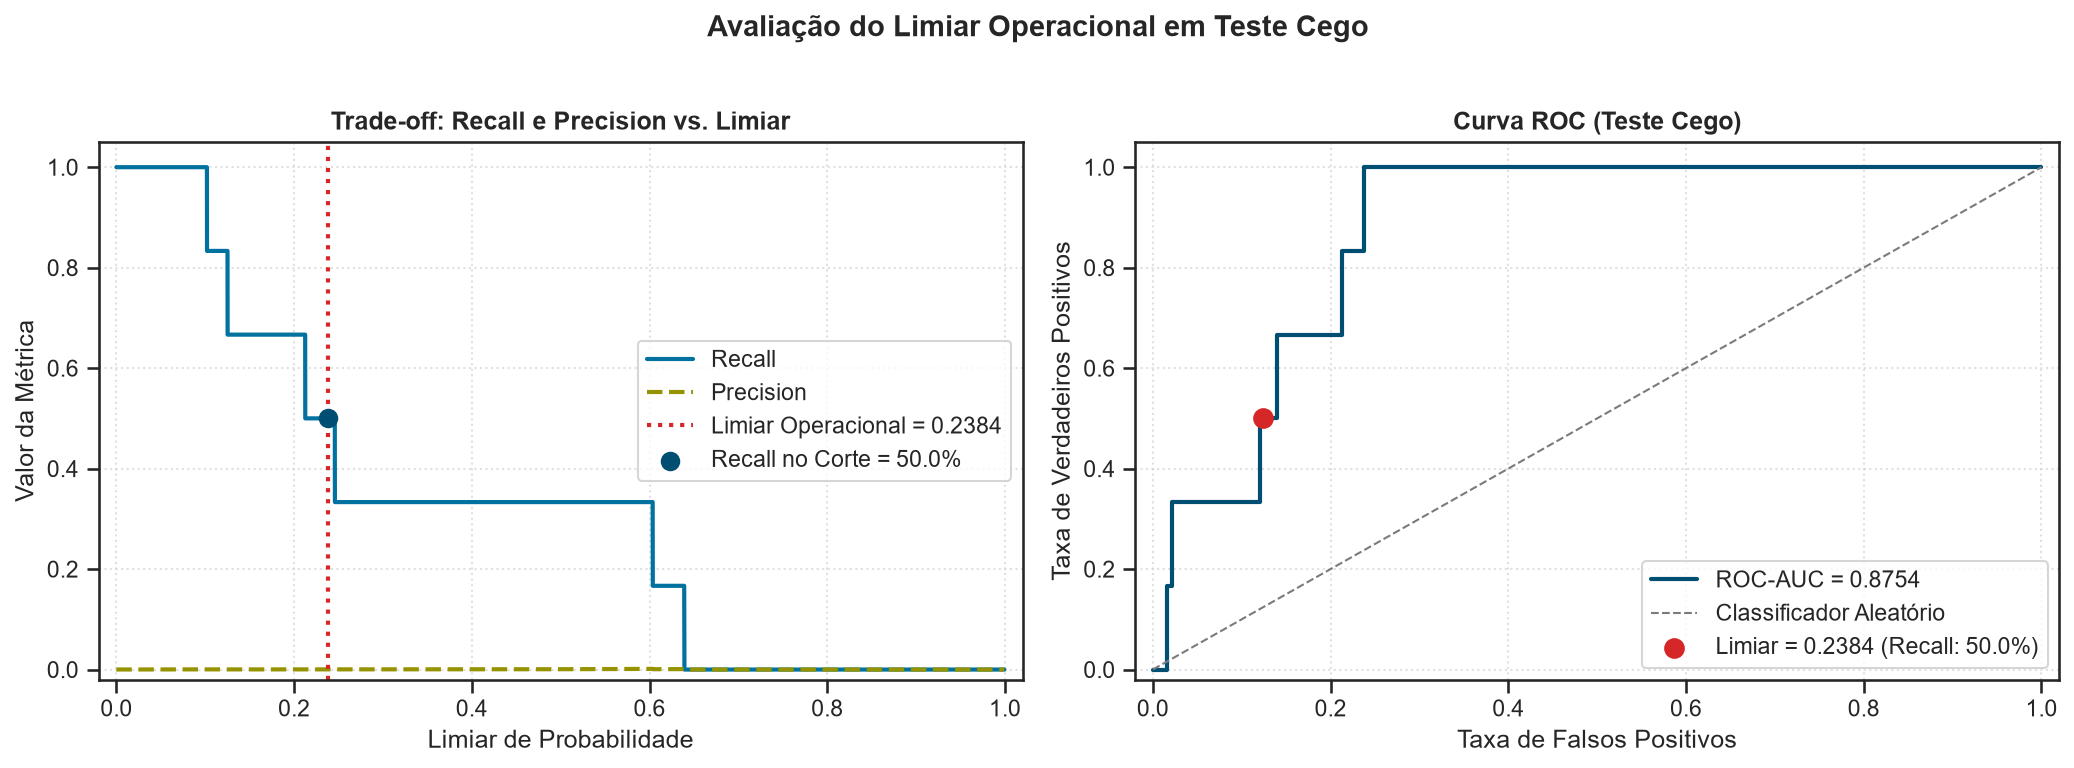


Gráfico salvo com sucesso em: ..\reports\figures\n06_threshold_evaluation.png


In [18]:
# Gráficos de avaliação do limiar operacional

full_image_path = FIGURE_THRESHOLD_EVALUATION
relative_image_path = os.path.relpath(full_image_path)

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_score)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)

roc_auc_value = roc_auc_score(y_test, y_score)
negative_cases = np.sum(np.asarray(y_test) == 0)


# Métricas no limiar operacional
operational_precision = precision_score(y_test, y_pred, zero_division=0)
operational_recall = recall_score(y_test, y_pred, zero_division=0)
operational_fpr = (
    np.sum((y_pred == 1) & (np.asarray(y_test) == 0)) / negative_cases
    if negative_cases > 0
    else np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# 1. Precision e Recall vs. Limiar (Threshold)
axes[0].plot(
    pr_thresholds,
    recalls[:-1],
    color=colors[1],
    linewidth=2,
    label="Recall",
)
axes[0].plot(
    pr_thresholds,
    precisions[:-1],
    color=colors[0],
    linewidth=2,
    linestyle="--",
    label="Precision",
)

# Linha vertical com o limiar calibrado
axes[0].axvline(
    x=threshold,
    color=additional_colors[3],
    linestyle=":",
    linewidth=2,
    label=f"Limiar Operacional = {threshold:.4f}",
)

# Destaque do Recall obtido
axes[0].scatter(
    [threshold],
    [operational_recall],
    color=colors[2],
    s=70,
    zorder=5,
    label=f"Recall no Corte = {operational_recall:.1%}",
)

axes[0].set_title("Trade-off: Recall e Precision vs. Limiar", fontweight="bold")
axes[0].set_xlabel("Limiar de Probabilidade")
axes[0].set_ylabel("Valor da Métrica")
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.05)
axes[0].legend(loc="center right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# 2. Curva ROC
axes[1].plot(
    fpr,
    tpr,
    color=colors[2],
    linewidth=2,
    label=f"ROC-AUC = {roc_auc_value:.4f}",
)
axes[1].plot(
    [0, 1],
    [0, 1],
    color=additional_colors[4],
    linestyle="--",
    linewidth=1,
    label="Classificador Aleatório",
)
axes[1].scatter(
    operational_fpr,
    operational_recall,
    color=additional_colors[3],
    s=80,
    zorder=5,
    label=f"Limiar = {threshold:.4f} (Recall: {operational_recall:.1%})",
)

axes[1].set_title("Curva ROC (Teste Cego)", fontweight="bold")
axes[1].set_xlabel("Taxa de Falsos Positivos")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=":", alpha=0.6)

fig.suptitle(
    "Avaliação do Limiar Operacional em Teste Cego",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("\nGráfico salvo com sucesso em: " f"{relative_image_path}")

- O gráfico da esquerda evidencia o comportamento em escada do Recall, por conta do número reduzido de casos positivos reais no conjunto de teste (apenas 6). Cada degrau representa a perda ou captura de uma ocorrência ($1/6 \approx 16,67\%$).

- O limiar de **0,2384** retém 50% de Recall, capturando **3 dos 6 eventos reais**. Com 8.575 de falsos positivos por 69.020 observações, a taxa de falsos positivos é de **12,42%**. Aumentos do limiar podem reduzir o Recall quando ultrapassam o próximo score relevante.

- A curva ROC à direita reforça a capacidade de ordenação do estimador. O ponto operacional apresenta 50% de Recall e deve ser interpretado em conjunto com a taxa de falsos positivos, não como uma garantia de desempenho futuro.

---

## 6. Comparativo de estabilidade e generalização temporal


A estabilidade temporal é avaliada pela comparação do ROC-AUC entre validação cruzada temporal, validação e teste cego. Essa análise verifica se a capacidade de ordenação do modelo permanece consistente em períodos posteriores.

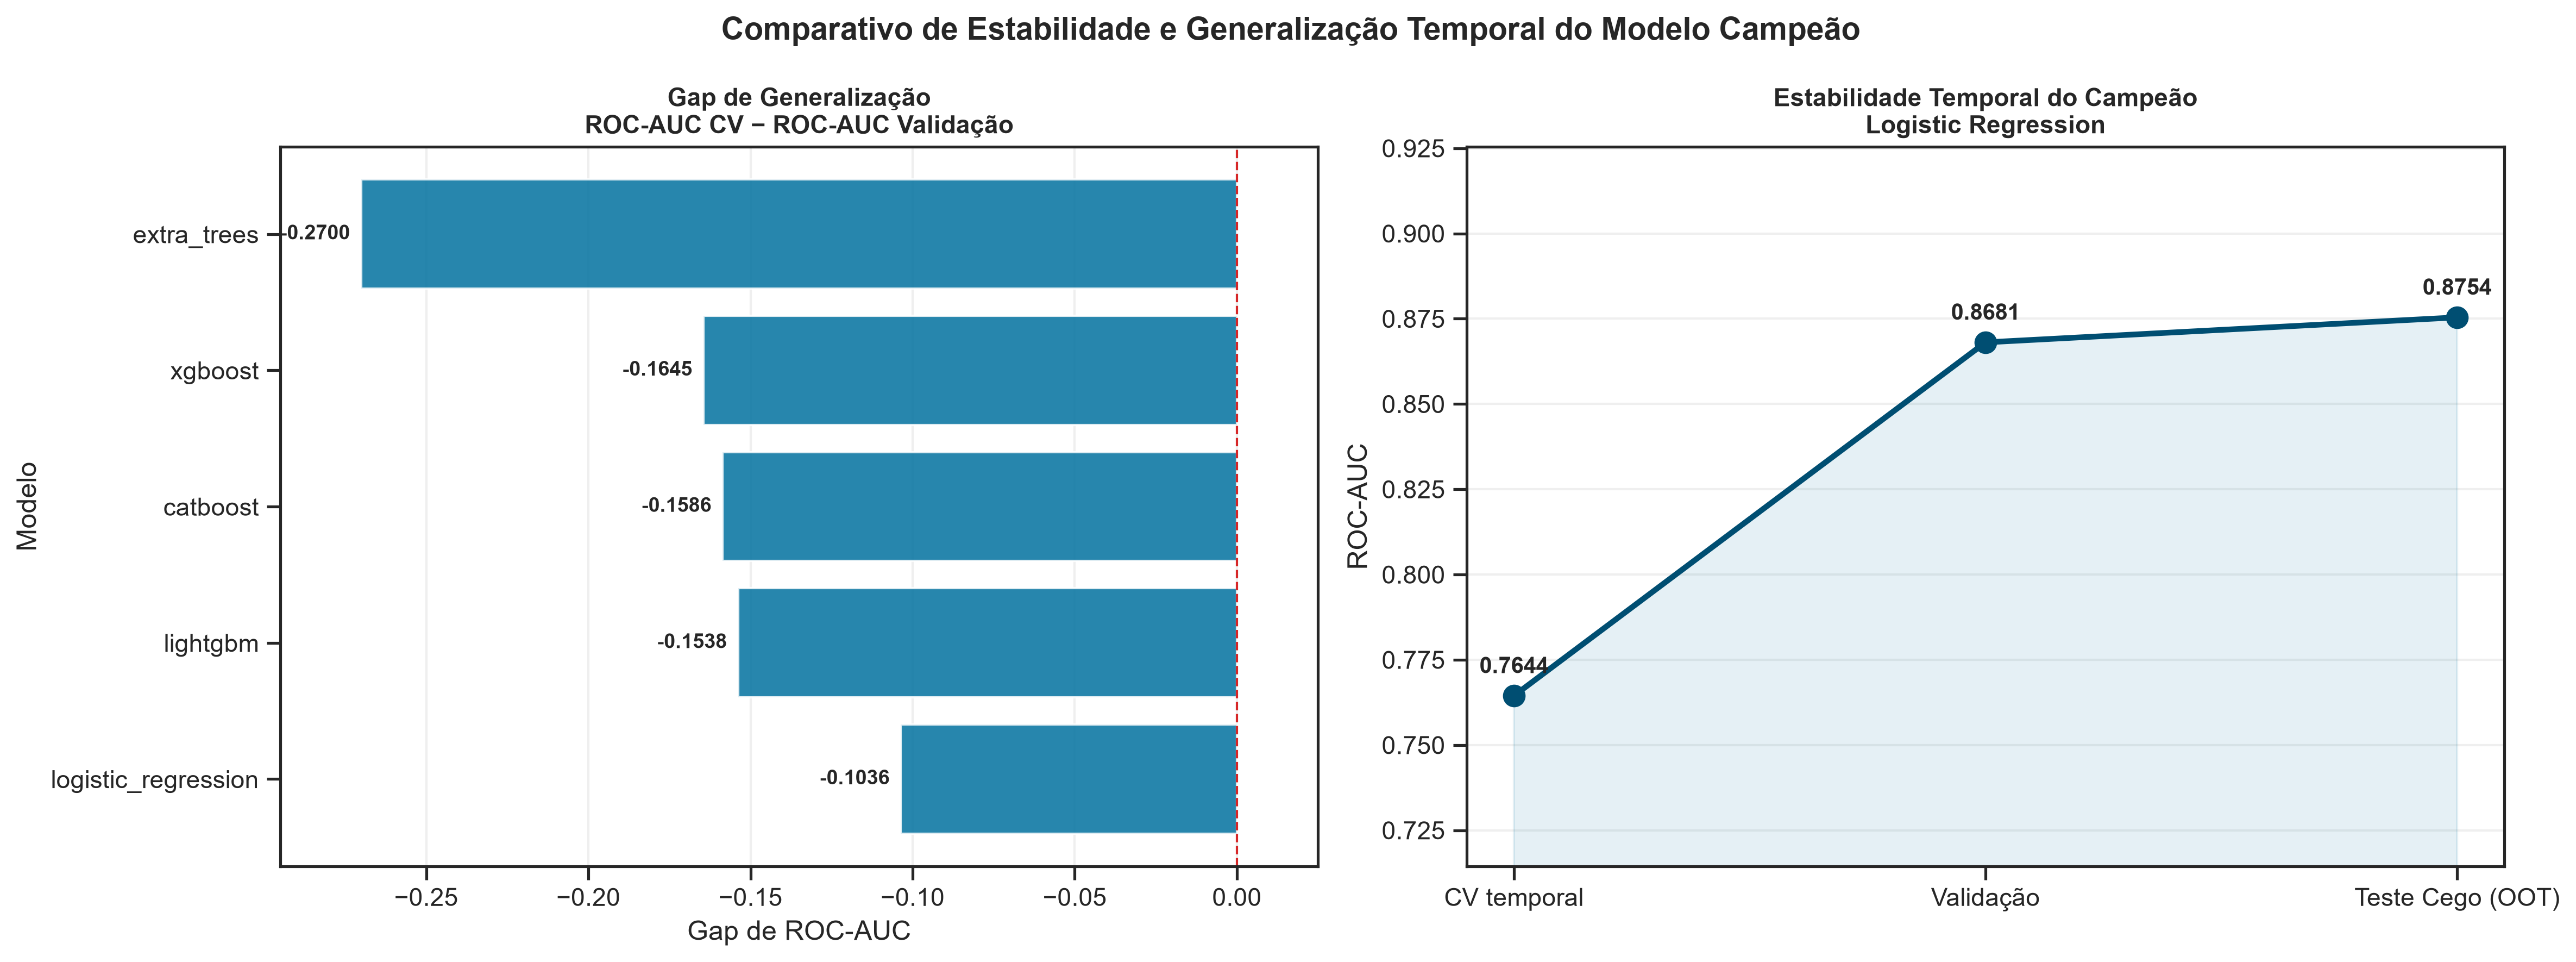


Gráfico salvo com sucesso em: ..\reports\figures\n06_generalization_comparative.png


In [19]:
# Comparativo de estabilidade e generalização temporal

full_image_path = FIGURE_GENERALIZATION_COMPARATIVE
relative_image_path = os.path.relpath(full_image_path)

required_files = [
    TABLE_TUNING_RESULTS,
    TABLE_OPERATIONAL_COMPARISON,
    TABLE_CHAMPION_METRICS,
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Arquivos necessários ausentes:\n" + "\n".join(missing_files)
    )

tuning_summary = pd.read_csv(TABLE_TUNING_RESULTS)
operational_comparison = pd.read_csv(TABLE_OPERATIONAL_COMPARISON)
champion_results = pd.read_csv(TABLE_CHAMPION_METRICS)

champion_model = model_name

df_cv_indexed = tuning_summary.set_index("modelo")
df_operational_indexed = operational_comparison.set_index("modelo")

if champion_model not in df_cv_indexed.index:
    raise KeyError(f"Modelo campeão não encontrado no tuning: {champion_model}")

if champion_model not in df_operational_indexed.index:
    raise KeyError(f"Modelo campeão não encontrado na validação: {champion_model}")

roc_cv = df_cv_indexed["roc_auc_cv"].astype(float)

roc_val = df_operational_indexed["roc_auc"].astype(float)

roc_test = float(
    champion_results.loc[
        champion_results["modelo"] == champion_model,
        "roc_auc",
    ].iloc[0]
)

modelos = roc_cv.index.tolist()

df_gap = pd.DataFrame(
    {
        "modelo": modelos,
        "ROC_AUC_CV": roc_cv.reindex(modelos).to_numpy(),
        "ROC_AUC_Validacao": roc_val.reindex(modelos).to_numpy(),
    }
)

df_gap["Gap_CV_Validacao"] = df_gap["ROC_AUC_CV"] - df_gap["ROC_AUC_Validacao"]

df_gap["Variacao_Absoluta"] = df_gap["Gap_CV_Validacao"].abs()

df_gap = df_gap.sort_values(
    "Variacao_Absoluta",
    ascending=True,
)

champion_cv_roc = float(roc_cv.loc[champion_model])
champion_validation_roc = float(roc_val.loc[champion_model])
champion_test_roc = roc_test

stages = [
    "CV temporal",
    "Validação",
    "Teste Cego (OOT)",
]

roc_values = [
    champion_cv_roc,
    champion_validation_roc,
    champion_test_roc,
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Gráfico 1: gap de generalização
ax1 = axes[0]

bars = ax1.barh(
    df_gap["modelo"],
    df_gap["Gap_CV_Validacao"],
    color=[
        colors[0] if value > 0.05 else colors[1] for value in df_gap["Gap_CV_Validacao"]
    ],
    alpha=0.85,
)

ax1.axvline(0, color=additional_colors[3], linestyle="--", linewidth=1)

ax1.set_title(
    "Gap de Generalização\nROC-AUC CV − ROC-AUC Validação",
    fontsize=11,
    fontweight="bold",
)

ax1.set_xlabel("Gap de ROC-AUC")
ax1.set_ylabel("Modelo")
ax1.grid(axis="x", alpha=0.3)

gap_min = df_gap["Gap_CV_Validacao"].min()
gap_max = df_gap["Gap_CV_Validacao"].max()
margin = max(0.02, (gap_max - gap_min) * 0.15)

ax1.set_xlim(
    min(0, gap_min) - margin,
    max(0, gap_max) + margin,
)

for bar in bars:
    value = bar.get_width()

    ax1.annotate(
        f"{value:+.4f}",
        (
            value,
            bar.get_y() + bar.get_height() / 2,
        ),
        ha="left" if value >= 0 else "right",
        va="center",
        xytext=(5 if value >= 0 else -5, 0),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

# Gráfico 2: estabilidade temporal do campeão
ax2 = axes[1]
x_stages = np.arange(len(stages))

ax2.plot(
    x_stages,
    roc_values,
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=colors[2],
)

ax2.fill_between(
    x_stages,
    roc_values,
    color=colors[1],
    alpha=0.1,
)

ax2.set_xticks(x_stages)
ax2.set_xticklabels(stages)
ax2.set_ylabel("ROC-AUC")

ax2.set_title(
    f"Estabilidade Temporal do Campeão\n" f"{champion_model.replace('_', ' ').title()}",
    fontsize=11,
    fontweight="bold",
)

ax2.grid(axis="y", alpha=0.3)

roc_min = min(roc_values)
roc_max = max(roc_values)
roc_margin = max(0.05, (roc_max - roc_min) * 0.25)

ax2.set_ylim(
    max(0.0, roc_min - roc_margin),
    min(1.02, roc_max + roc_margin),
)

for x_value, y_value in zip(x_stages, roc_values):
    ax2.annotate(
        f"{y_value:.4f}",
        (x_value, y_value),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

fig.suptitle(
    "Comparativo de Estabilidade e Generalização Temporal " "do Modelo Campeão",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("\nGráfico salvo com sucesso em: " f"{relative_image_path}")

* A diferença entre a média da validação cruzada temporal e a partição de validação atua como um diagnóstico comparativo de estabilidade temporal, não devendo ser tomada isoladamente como evidência estrita de overfitting. Como todos os modelos registraram valores negativos no gráfico à esquerda, o desempenho na validação foi numericamente superior ao observado durante os folds de treino cruzado.

* Entre os estimadores avaliados, a `logistic_regression` exibiu a menor divergência entre as etapas, com um gap de **-0,1036**. Por outro lado, os demais modelos apresentaram maiores desvios, evidenciando uma oscilação bem maior em dados temporais recentes.

* O gráfico à direita ilustra a trajetória sustentada da `logistic_regression` através de todas as fases temporais do pipeline. O modelo partiu de um ROC-AUC de **0,7644** no CV temporal, ascendeu para **0,8681** na Validação e consolidou **0,8754** na base de Teste Cego (OOT), confirmando preservação contínua da capacidade de ordenação nos dados não vistos.

---

## 7. Análise dos erros

Este tópico identifica os verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos no conjunto de teste. Além disso, é realizada a análise do limiar operacional e trade-off entre recall e falsos positivos.

### 7.1. Auditoria de falsos negativos

In [20]:
# Auditoria de falsos negativos

full_table_path = TABLE_FALSE_NEGATIVES_AUDIT
relative_table_path = os.path.relpath(full_table_path)

df_audit = X_test.copy().reset_index(drop=True)

df_audit["Score_Risco"] = np.asarray(y_score)
df_audit["Pred_Operacional"] = np.asarray(y_pred)
df_audit["Real"] = np.asarray(y_test).astype("int8")

conditions = [
    (df_audit["Real"] == 1) & (df_audit["Pred_Operacional"] == 1),
    (df_audit["Real"] == 1) & (df_audit["Pred_Operacional"] == 0),
    (df_audit["Real"] == 0) & (df_audit["Pred_Operacional"] == 1),
    (df_audit["Real"] == 0) & (df_audit["Pred_Operacional"] == 0),
]

choices = [
    "Verdadeiro Positivo (TP)",
    "Falso Negativo (FN)",
    "Falso Positivo (FP)",
    "Verdadeiro Negativo (TN)",
]

df_audit["Classificacao_Erro"] = np.select(
    conditions,
    choices,
    default="Indefinido",
)

analysis_cols = [
    "IdeConjunto",
    "DistribuidoraKey",
    "Ano",
    "MesNumero",
    "SigIndicador",
    "Score_Risco",
    "NumConsumidores",
    "PercLimite_Lag1",
    "Indicador_Lag1",
]

cols_show = [coluna for coluna in analysis_cols if coluna in df_audit.columns]

df_fn = df_audit.loc[
    df_audit["Classificacao_Erro"] == "Falso Negativo (FN)",
    cols_show,
]

print(f"Falsos negativos encontrados: {len(df_fn):,}")

display(
    df_fn.style.format(
        {
            "Score_Risco": "{:.4%}",
            "PercLimite_Lag1": "{:.2%}",
            "Indicador_Lag1": "{:.2f}",
            "NumConsumidores": "{:,.0f}",
        },
        na_rep="—",
    )
)


df_fn.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

Falsos negativos encontrados: 3


,Ano,Score_Risco
50702,2025,10.1911%
63946,2025,21.2490%
64188,2025,12.5075%



Tabela salva com sucesso em: ..\docs\metadata\n06_false_negatives_audit.csv


In [21]:
# Comparativo do perfil dos casos

full_table_path = TABLE_ERROR_CLASSIFICATION_PROFILE
relative_table_path = os.path.relpath(full_table_path)

features_profile = [
    coluna
    for coluna in [
        "PercLimite_Lag1",
        "Indicador_Lag1",
        "NumConsumidores",
        "Score_Risco",
    ]
    if coluna in df_audit.columns
]

profile_summary = (
    df_audit
    .groupby("Classificacao_Erro")[features_profile]
    .agg(["mean", "median"])
)

print("\nPERFIL DE CLASSIFICAÇÃO DOS ERROS")

display(
    profile_summary.style.format(
        "{:.4f}",
        na_rep="—",
    )
)

profile_export = profile_summary.copy()
profile_export.columns = [
    f"{feature}_{statistics}"
    for feature, statistics in profile_export.columns
]

profile_export = profile_export.reset_index()

profile_export.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")


PERFIL DE CLASSIFICAÇÃO DOS ERROS



Tabela salva com sucesso em: ..\docs\metadata\n06_error_classification_profile.csv


- As três ocorrências reais que não atingiram o limiar operacional apresentaram probabilidades atribuídas de **10,19%**, **12,51%** e **21,25%**. A média e mediana deste grupo comprovam que foram transgressões sem sinais prévios evidentes de degradação nos indicadores históricos do mês anterior.

- Um dos falsos negativos quase foi capturado pelo modelo com valor de **21,25%**, ficando bem próximo do limiar operacional de **23,84%**.

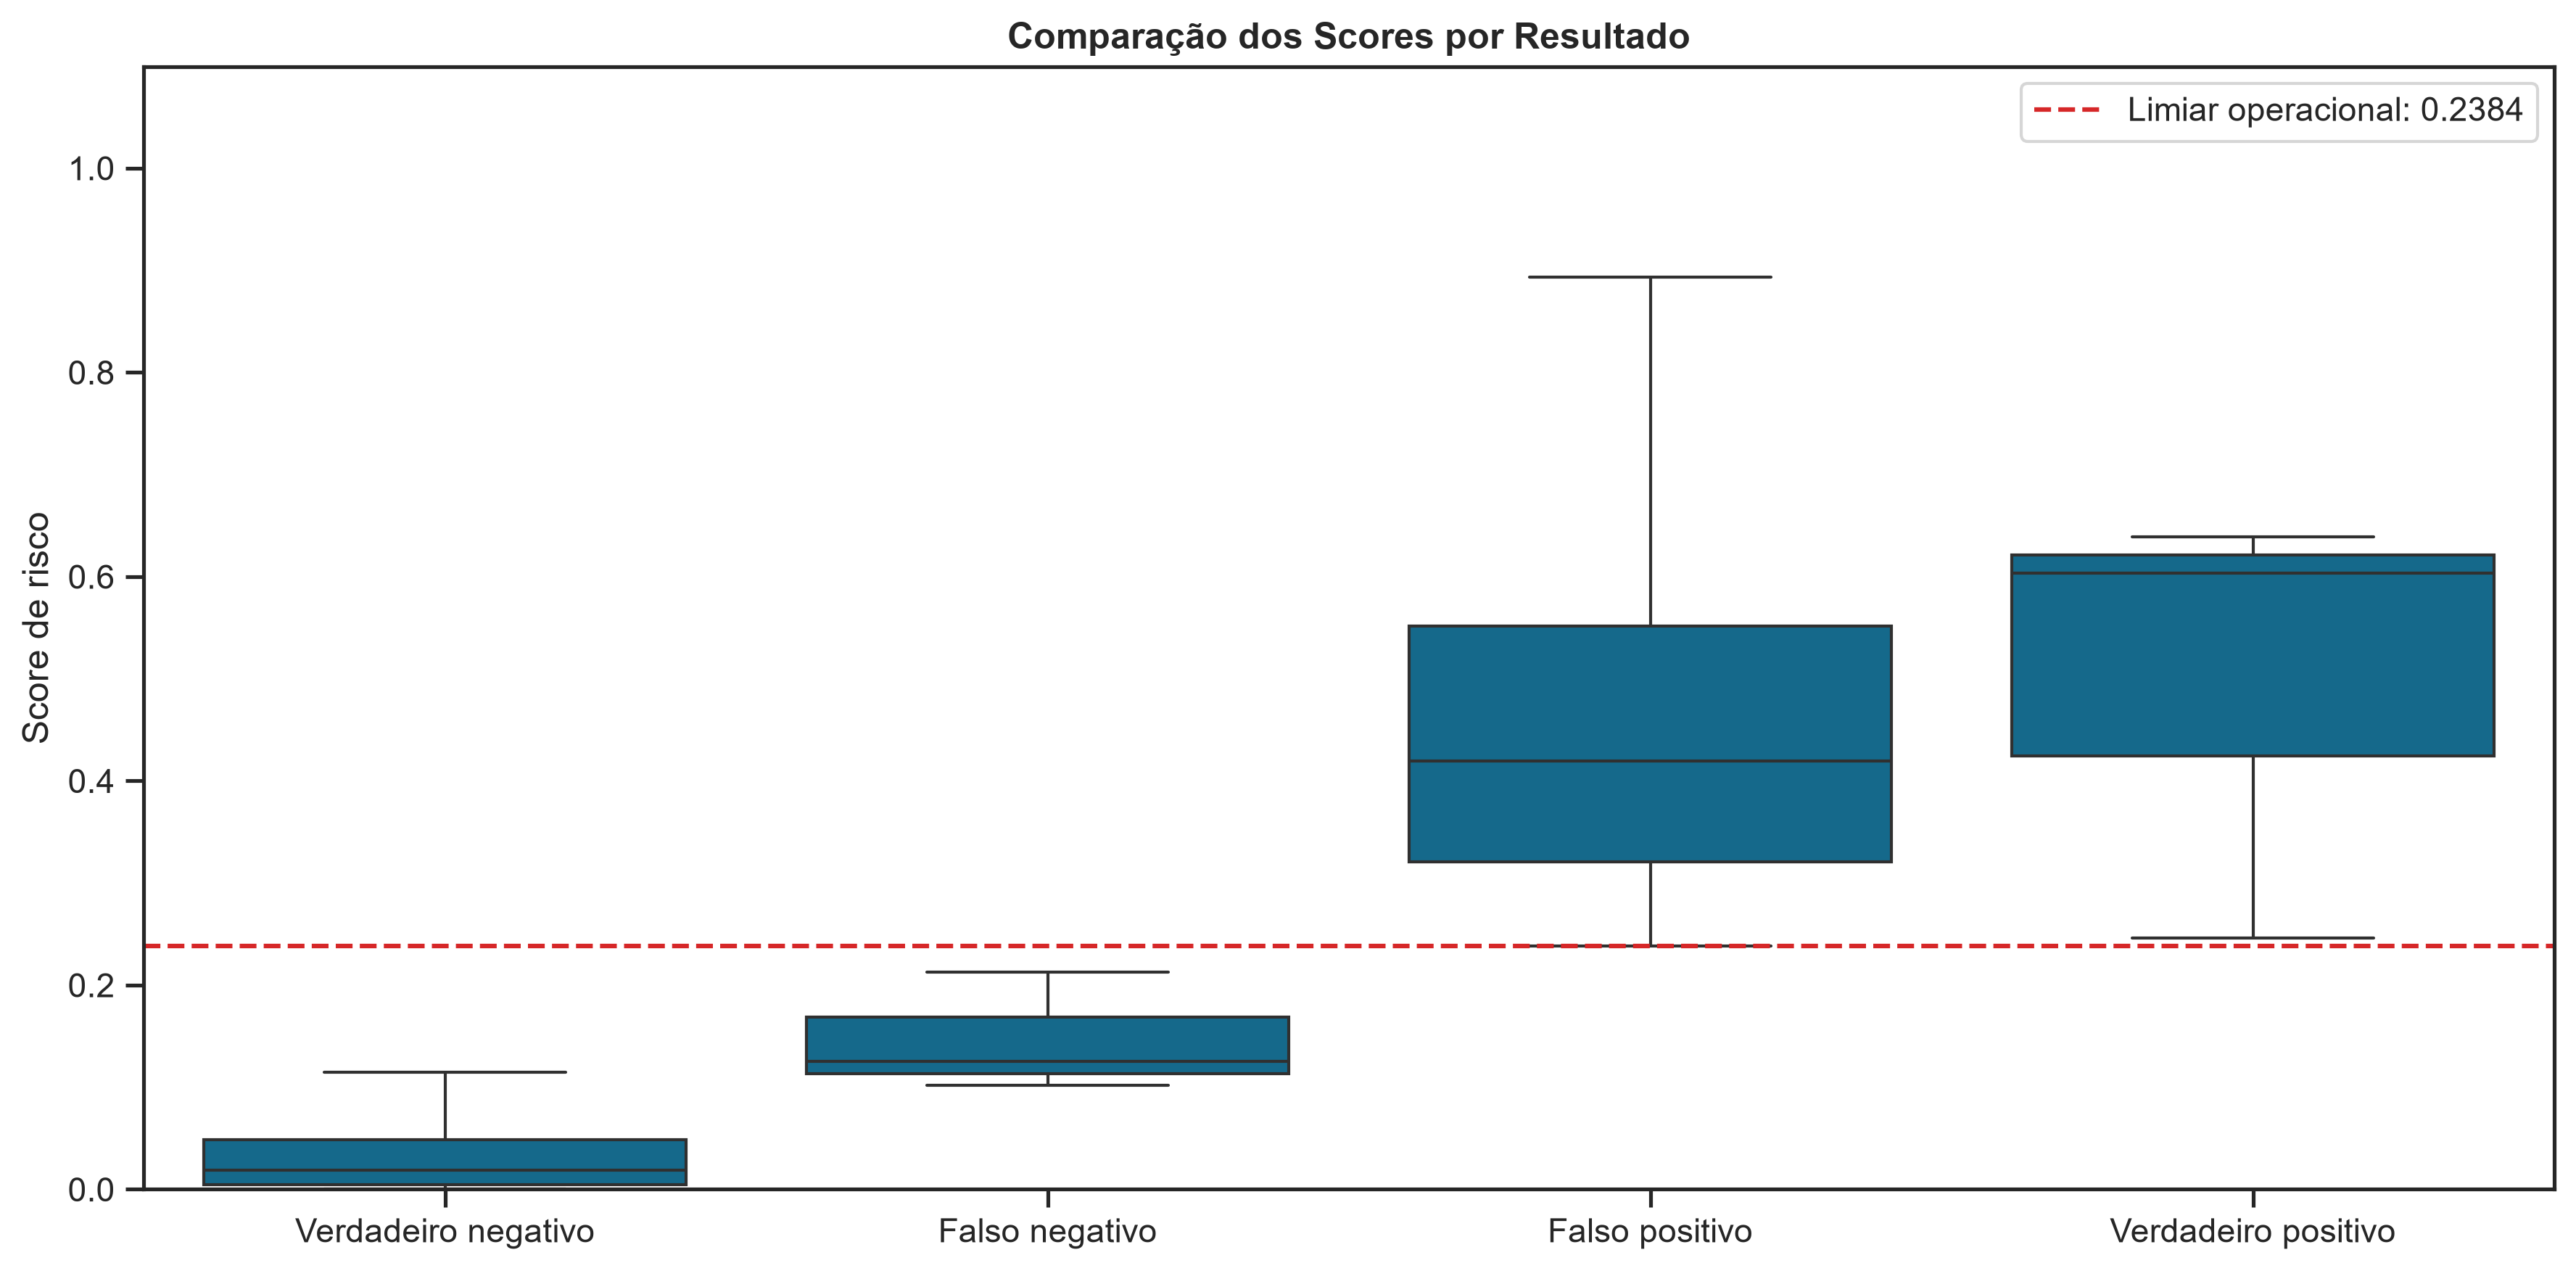


Gráfico salvo com sucesso em: ..\reports\figures\n06_error_classification_profile.png


In [22]:
# Gráfico comparativo de classificação dos erros

full_image_path = FIGURE_ERROR_SCORE_COMPARISON
relative_image_path = os.path.relpath(full_image_path)

df_boxplot = pd.DataFrame(
    {
        "score_risco": np.asarray(y_score),
        "valor_real": np.asarray(y_test).astype("int8"),
        "previsao": np.asarray(y_pred).astype("int8"),
    }
)

df_boxplot["tipo_erro"] = np.select(
    [
        (df_boxplot["valor_real"] == 0) & (df_boxplot["previsao"] == 0),
        (df_boxplot["valor_real"] == 0) & (df_boxplot["previsao"] == 1),
        (df_boxplot["valor_real"] == 1) & (df_boxplot["previsao"] == 0),
        (df_boxplot["valor_real"] == 1) & (df_boxplot["previsao"] == 1),
    ],
    [
        "Verdadeiro negativo",
        "Falso positivo",
        "Falso negativo",
        "Verdadeiro positivo",
    ],
    default="Indefinido",
)

order = [
    "Verdadeiro negativo",
    "Falso negativo",
    "Falso positivo",
    "Verdadeiro positivo",
]

available_order = [
    category for category in order if category in df_boxplot["tipo_erro"].unique()
]

boxplot_palette = {category: colors[1] for category in order}

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

sns.boxplot(
    data=df_boxplot,
    x="tipo_erro",
    y="score_risco",
    order=available_order,
    hue="tipo_erro",
    hue_order=order,
    palette=boxplot_palette,
    showfliers=False,
    legend=False,
    ax=ax,
)

ax.axhline(
    threshold,
    color=additional_colors[3],
    linestyle="--",
    linewidth=1.5,
    label=f"Limiar operacional: {threshold:.4f}",
)

ax.set_title(
    "Comparação dos Scores por Resultado",
    fontweight="bold",
)

ax.set_xlabel("")
ax.set_ylabel("Score de risco")
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, max(float(np.max(y_score)), threshold) * 1.10)
ax.legend()

plt.tight_layout()
plt.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("\nGráfico salvo com sucesso em: " f"{relative_image_path}")

- No boxplot, é possível verificar que ambos os verdadeiros negativos e os falsos negativos estão próximos a zero, mostrando que a maioria da rede regular não gera ruído desnecessário.

- Os falsos positivos e verdadeiros positivos claramente deslocados para cima da linha de corte comprovam que o modelo só atribui pontuações altas a conjuntos com histórico relevante de risco.

### 7.2. Limiar operacional, recall e falsos positivos

In [23]:
# Análise de limiar operacional e trade-off entre recall e falsos positivos

full_table_path = TABLE_TRADEOFF_RECALL_FP
relative_table_path = os.path.relpath(full_table_path)

scores = np.asarray(y_score, dtype=float)
y_true = np.asarray(y_test, dtype=int)

# Ordena os scores do maior para o menor e agrupa scores iguais.
order = np.argsort(-scores, kind="mergesort")
scores_sorted = scores[order]
y_sorted = y_true[order]
group_end = np.r_[np.flatnonzero(np.diff(scores_sorted)) + 1, len(scores_sorted)]

thresholds = scores_sorted[group_end - 1]
tp_values = np.cumsum(y_sorted)[group_end - 1]
fp_values = np.cumsum(1 - y_sorted)[group_end - 1]
total_positives = y_true.sum()
total_negatives = len(y_true) - total_positives

threshold_analysis_df = pd.DataFrame(
    {
        "limiar": thresholds,
        "TP": tp_values.astype(int),
        "FP": fp_values.astype(int),
        "FN": (total_positives - tp_values).astype(int),
        "TN": (total_negatives - fp_values).astype(int),
    }
)

if threshold_analysis_df["limiar"].iloc[-1] > 0:
    threshold_analysis_df = pd.concat(
        [
            threshold_analysis_df,
            pd.DataFrame(
                [
                    {
                        "limiar": 0.0,
                        "TP": int(total_positives),
                        "FP": int(total_negatives),
                        "FN": 0,
                        "TN": 0,
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

threshold_analysis_df["recall"] = threshold_analysis_df["TP"] / max(total_positives, 1)
threshold_analysis_df["precision"] = (
    threshold_analysis_df["TP"]
    / (threshold_analysis_df["TP"] + threshold_analysis_df["FP"]).replace(0, np.nan)
).fillna(0)

max_plot_points = 300
if len(threshold_analysis_df) > max_plot_points:
    plot_indexes = np.linspace(
        0, len(threshold_analysis_df) - 1, max_plot_points, dtype=int
    )
    plot_df = threshold_analysis_df.iloc[plot_indexes].copy()
else:
    plot_df = threshold_analysis_df.copy()

display(threshold_analysis_df[threshold_analysis_df["FP"] > 0].head(10))

threshold_analysis_df.to_parquet(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")


,limiar,TP,FP,FN,TN,recall,precision
0,1.00,0,1,6,69019,0.00,0.00
1,1.00,0,2,6,69018,0.00,0.00
2,1.00,0,3,6,69017,0.00,0.00
3,0.99,0,4,6,69016,0.00,0.00
4,0.99,0,5,6,69015,0.00,0.00
5,0.99,0,6,6,69014,0.00,0.00
6,0.99,0,7,6,69013,0.00,0.00
7,0.99,0,8,6,69012,0.00,0.00
8,0.98,0,9,6,69011,0.00,0.00
9,0.98,0,10,6,69010,0.00,0.00



Tabela salva com sucesso em: ..\docs\metadata\n06_tradeoff_recall_fp.parquet


Modelo avaliado: logistic_regression
Os falsos positivos começam no limiar 0.99934439.
Falsos positivos no ponto: 1


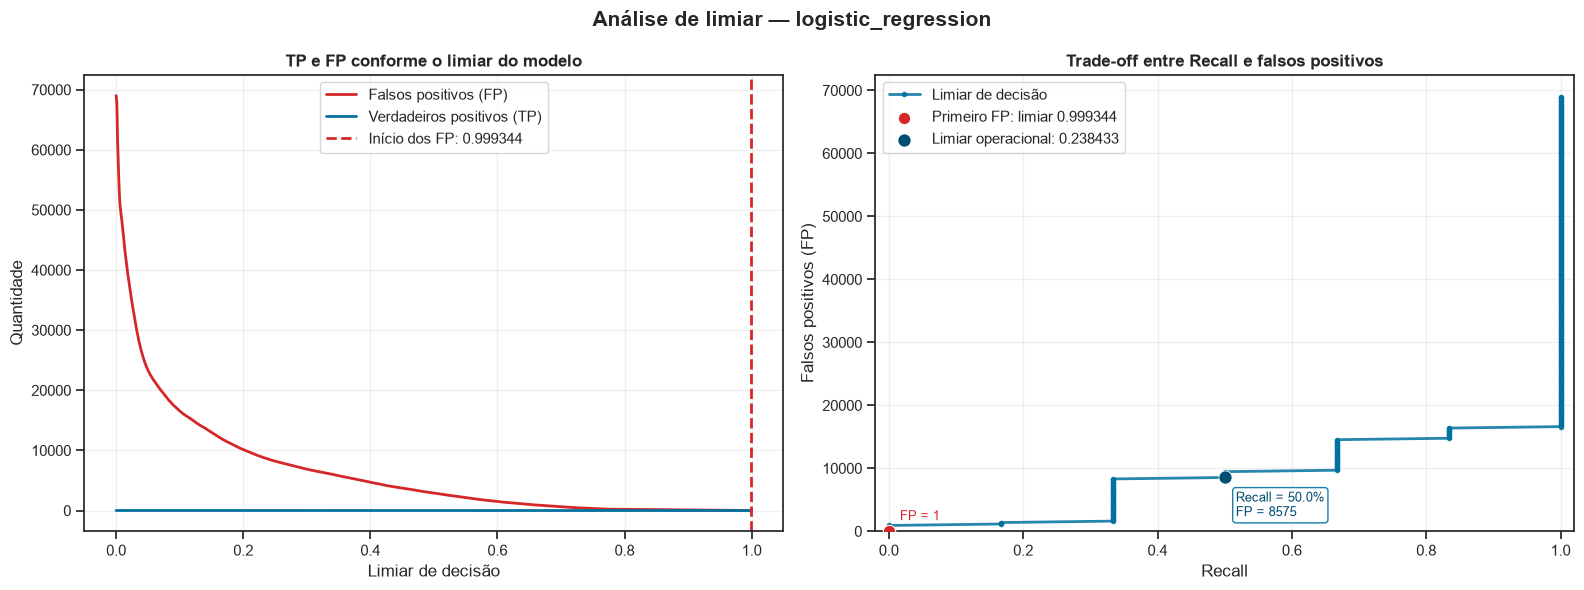


Gráfico salvo com sucesso em: ..\reports\figures\n06_tradeoff_recall_fp.png


In [24]:
# Gráficos de trade-off entre recall e falsos positivos

full_image_path = FIGURE_TRADEOFF_RECALL_FP
relative_image_path = os.path.relpath(full_image_path)

fp_rows = threshold_analysis_df[threshold_analysis_df["FP"] > 0]
if fp_rows.empty:
    print("O modelo não gerou falsos positivos no teste cego.")
else:
    first_fp = fp_rows.iloc[0]
    print(f"Modelo avaliado: {model_name}")
    print(f"Os falsos positivos começam no limiar {first_fp['limiar']:.8f}.")
    print(f"Falsos positivos no ponto: {int(first_fp['FP'])}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: TP e FP conforme o limiar do modelo
axes[0].plot(
    plot_df["limiar"],
    plot_df["FP"],
    linewidth=2,
    color=additional_colors[3],
    label="Falsos positivos (FP)",
)
axes[0].plot(
    plot_df["limiar"],
    plot_df["TP"],
    linewidth=2,
    color=colors[1],
    label="Verdadeiros positivos (TP)",
)
if not fp_rows.empty:
    axes[0].axvline(
        first_fp["limiar"],
        color=additional_colors[3],
        linestyle="--",
        linewidth=2,
        label=f"Início dos FP: {first_fp['limiar']:.6f}",
    )
axes[0].set_title("TP e FP conforme o limiar do modelo", fontweight="bold")
axes[0].set_xlabel("Limiar de decisão")
axes[0].set_ylabel("Quantidade") 
axes[0].grid(alpha=0.3)
axes[0].legend()

# Gráfico 2: trade-off entre recall e falsos positivos
tradeoff_df = plot_df.sort_values(["recall", "FP"], ascending=[True, True])
axes[1].plot(
    tradeoff_df["recall"],
    tradeoff_df["FP"],
    color=colors[1],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85,
    label="Limiar de decisão",
)
if not fp_rows.empty:
    axes[1].scatter(
        first_fp["recall"],
        first_fp["FP"],
        color=additional_colors[3],
        edgecolor="white",
        linewidth=0.8,
        s=80,
        zorder=5,
        label=f"Primeiro FP: limiar {first_fp['limiar']:.6f}",
    )
    axes[1].annotate(
        f"FP = {int(first_fp['FP'])}",
        (first_fp["recall"], first_fp["FP"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        color=additional_colors[3],
    )

operational_index = (threshold_analysis_df["limiar"] - float(threshold)).abs().idxmin()
operational_row = threshold_analysis_df.loc[operational_index]
axes[1].scatter(
    operational_row["recall"],
    operational_row["FP"],
    color=colors[2],
    edgecolor="white",
    linewidth=0.6,
    s=90,
    zorder=6,
    label=f"Limiar operacional: {threshold:.6f}",
)
axes[1].annotate(
    f"Recall = {operational_row['recall']:.1%}\nFP = {int(operational_row['FP'])}",
    (operational_row["recall"], operational_row["FP"]),
    xytext=(8, -28),
    textcoords="offset points",
    fontsize=9,
    color=colors[2],
    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": colors[1], "alpha": 0.9},
)
axes[1].set_title("Trade-off entre Recall e falsos positivos", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Falsos positivos (FP)")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle(f"Análise de limiar — {model_name}", fontsize=15, fontweight="bold")
fig.tight_layout()

fig.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"\nGráfico salvo com sucesso em: {relative_image_path}")

- No gráfico da esquerda, observa-se que a quantidade de falsos positivos aumenta à medida que o limiar de decisão desce em direção a zero, refletindo o severo desbalanceamento da base.

- O primeiro falso positivo surge no limiar de aproximadamente `0,9993`, indicando sobreposição entre os scores dos casos negativos e positivos mesmo na extremidade superior da distribuição.

- No gráfico da direita, os saltos refletem a escassez absoluta de eventos positivos na base. Cada salto representa a captura de um novo caso real acompanhada pela acumulação de falsos positivos.

- O limiar operacional fixa o modelo em **50% de Recall** com **8.575 falsos positivos**.

---

## 8. Análise dos resíduos

Nesta seção são apresentados os resíduos do modelo. Os resíduos são calculados pela diferença entre a classe real e o score de risco previsto. O gráfico permite identificar padrões de erro, especialmente observações reais subestimadas ou superestimadas pelo modelo.

In [25]:
# Resíduos probabilísticos e de classificação

full_table_path = TABLE_RESIDUALS
relative_table_path = os.path.relpath(full_table_path)

residuals_df = pd.DataFrame(
    {
        "Score_Risco": np.asarray(y_score, dtype=float),
        "Classe_Real": np.asarray(y_test).astype("int8"),
        "Previsao": np.asarray(y_pred).astype("int8"),
    }
)

residuals_df["Residuo_Probabilistico"] = (
    residuals_df["Classe_Real"] - residuals_df["Score_Risco"]
)

residuals_df["Residuo_Classificacao"] = (
    residuals_df["Classe_Real"] - residuals_df["Previsao"]
)

residuals_df["Classe_Descritiva"] = residuals_df["Classe_Real"].map(
    {
        0: "Sem transgressão",
        1: "Com transgressão",
    }
)

display(residuals_df.head(10).style.format({"Score_Risco": "{:.4%}"}))


residuals_df.to_parquet(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")


,Score_Risco,Classe_Real,Previsao,Residuo_Probabilistico,Residuo_Classificacao,Classe_Descritiva
0,1.1181%,0,0,-0.011181,0,Sem transgressão
1,0.9505%,0,0,-0.009505,0,Sem transgressão
2,0.8372%,0,0,-0.008372,0,Sem transgressão
3,0.9544%,0,0,-0.009544,0,Sem transgressão
4,1.2373%,0,0,-0.012373,0,Sem transgressão
5,1.6145%,0,0,-0.016145,0,Sem transgressão
6,2.5845%,0,0,-0.025845,0,Sem transgressão
7,3.1010%,0,0,-0.031010,0,Sem transgressão
8,2.7455%,0,0,-0.027455,0,Sem transgressão
9,2.4954%,0,0,-0.024954,0,Sem transgressão



Tabela salva com sucesso em: ..\docs\metadata\n06_residuals.parquet


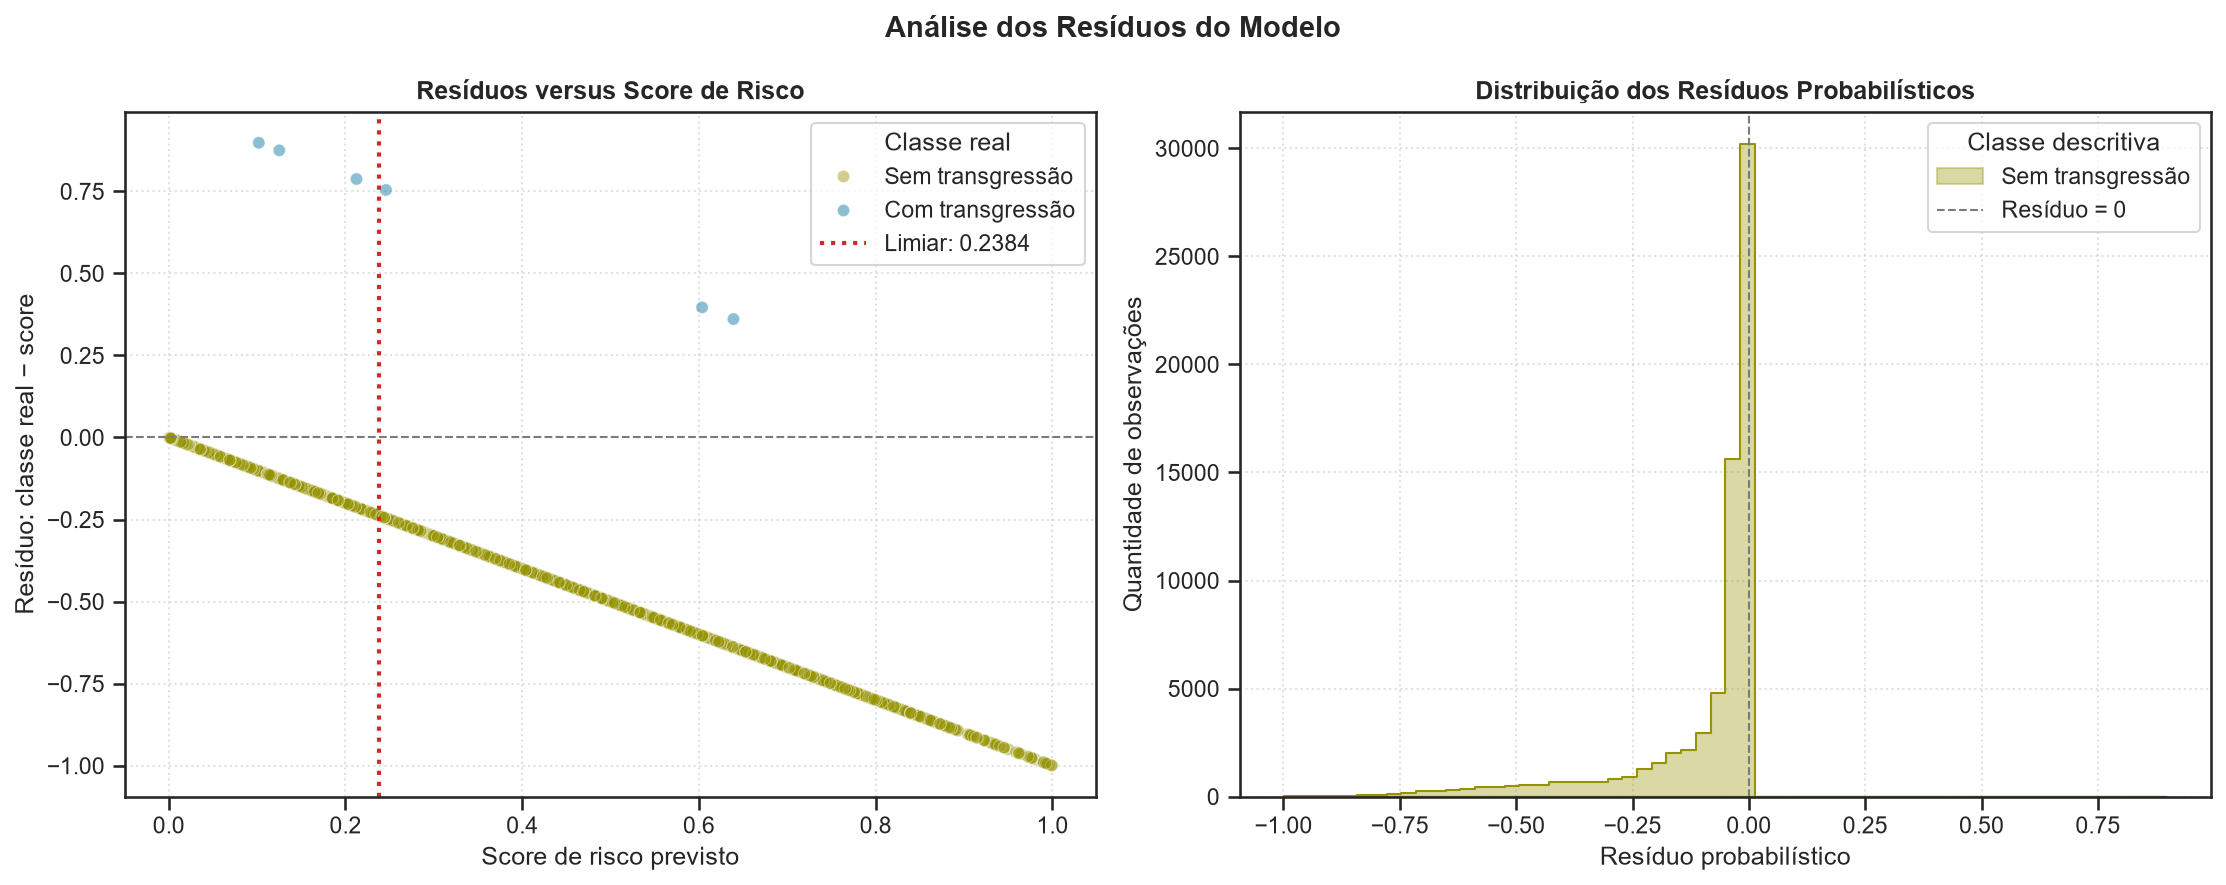


Gráfico salvo com sucesso em: ..\reports\figures\n06_residuals.png


In [26]:
# Gráfico dos resíduos do modelo

full_image_path = FIGURE_RESIDUALS
relative_image_path = os.path.relpath(full_image_path)


palette_desc = {
    "Sem transgressão": colors[0],
    "Com transgressão": colors[1],
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    dpi=150,
)

# Resíduo probabilístico versus score previsto
sns.scatterplot(
    data=residuals_df,
    x="Score_Risco",
    y="Residuo_Probabilistico",
    hue="Classe_Descritiva",
    palette=palette_desc,
    alpha=0.45,
    s=35,
    ax=axes[0],
)

axes[0].axhline(
    0,
    color=additional_colors[4],
    linestyle="--",
    linewidth=1,
)

axes[0].axvline(
    threshold,
    color=additional_colors[3],
    linestyle=":",
    linewidth=2,
    label=f"Limiar: {threshold:.4f}",
)

axes[0].set_title(
    "Resíduos versus Score de Risco",
    fontweight="bold",
)

axes[0].set_xlabel("Score de risco previsto")
axes[0].set_ylabel("Resíduo: classe real − score")
axes[0].legend(title="Classe real")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Distribuição dos resíduos probabilísticos
sns.histplot(
    data=residuals_df,
    x="Residuo_Probabilistico",
    hue="Classe_Descritiva",
    bins=60,
    element="step",
    fill=True,
    alpha=0.35,
    palette=palette_desc,
    ax=axes[1],
)

axes[1].axvline(
    0,
    color=additional_colors[4],
    linestyle="--",
    linewidth=1,
)


axes[1].set_title(
    "Distribuição dos Resíduos Probabilísticos",
    fontweight="bold",
)

axes[1].set_xlabel("Resíduo probabilístico")
axes[1].set_ylabel("Quantidade de observações")
axes[1].grid(True, linestyle=":", alpha=0.6)

residual_legend_handles = [
    Patch(
        facecolor=colors[0],
        edgecolor=colors[0],
        alpha=0.35,
        label="Sem transgressão",
    ),
    Line2D(
        [0],
        [0],
        color=additional_colors[4],
        linestyle="--",
        linewidth=1,
        label="Resíduo = 0",
    ),
]

axes[1].legend(
    handles=residual_legend_handles,
    title="Classe descritiva",
)

fig.suptitle(
    "Análise dos Resíduos do Modelo",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"\nGráfico salvo com sucesso em: {relative_image_path}")

- O resíduo probabilístico é calculado como `classe real − score previsto`. Para observações sem transgressão, tende a ser negativo; para observações com transgressão, tende a ser positivo.

- O limiar operacional de `0,2384` é utilizado apenas para transformar o score em uma previsão binária. Portanto, ele não representa a fronteira do resíduo, mas a regra de decisão do modelo.

- No gráfico à esquerda, os falsos negativos correspondem às observações reais positivas cujo score ficou à esquerda do limiar operacional. Os verdadeiros positivos são as observações reais positivas posicionadas à direita do limiar.

---

## 9. Importância e Pesos dos Atributos

Esta seção extrai os coeficientes diretamente do estimador treinado e gera o gráfico com os fatores que mais impulsionam o risco de transgressão.

In [27]:
# Importância das features (coeficientes da regressão logística)

full_table_path = TABLE_FEATURE_IMPORTANCE
relative_table_path = os.path.relpath(full_table_path)

if hasattr(model, "named_steps"):
    classifier = model.steps[-1][1]
    preprocessor = model[:-1]

    if hasattr(preprocessor, "get_feature_names_out"):
        feature_names = preprocessor.get_feature_names_out(
            input_features=X_test.columns
        )
    else:
        feature_names = np.asarray(X_test.columns)
else:
    classifier = model
    feature_names = np.asarray(X_test.columns)

if not hasattr(classifier, "coef_"):
    raise AttributeError(
        f"O classificador {type(classifier).__name__} "
        "não possui coeficientes 'coef_'."
    )

coefs = np.asarray(classifier.coef_)

if coefs.ndim == 2:
    coefs = coefs[0]

feature_names = np.asarray(feature_names, dtype=str)

if len(feature_names) != len(coefs):
    raise ValueError(
        f"Número de atributos ({len(feature_names)}) diferente do "
        f"número de coeficientes ({len(coefs)})."
    )

df_coefs = pd.DataFrame(
    {
        "Atributo": feature_names,
        "Coeficiente": coefs,
    }
)

df_coefs["Impacto_Absoluto"] = df_coefs["Coeficiente"].abs()

top_features = (
    df_coefs.sort_values("Impacto_Absoluto", ascending=False)
    .head(15)
    .sort_values("Coeficiente")
)

display(
    top_features[["Atributo", "Coeficiente", "Impacto_Absoluto"]].style.format(
        {
            "Coeficiente": "{:.8f}",
            "Impacto_Absoluto": "{:.8f}",
        }
    )
)

top_features.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,Atributo,Coeficiente,Impacto_Absoluto
13,SigIndicador_FEC,-0.50618405,0.50618405
10,mes_seno,-0.45669445,0.45669445
80,SigAgente_CPFL-PAULISTA,-0.29437326,0.29437326
76,SigAgente_COPEL-DIS,-0.27284117,0.27284117
66,SigAgente_COELBA,-0.26817715,0.26817715
99,SigAgente_EMT,-0.26540113,0.26540113
93,SigAgente_ELEKTRO,-0.24950129,0.24950129
2,VlrLimite,-0.24211896,0.24211896
106,SigAgente_EQUATORIAL MA,0.33286185,0.33286185
27,SigAgente_CELESC,0.38874590,0.38874590



Tabela salva com sucesso em: ..\docs\metadata\n06_feature_importance.csv


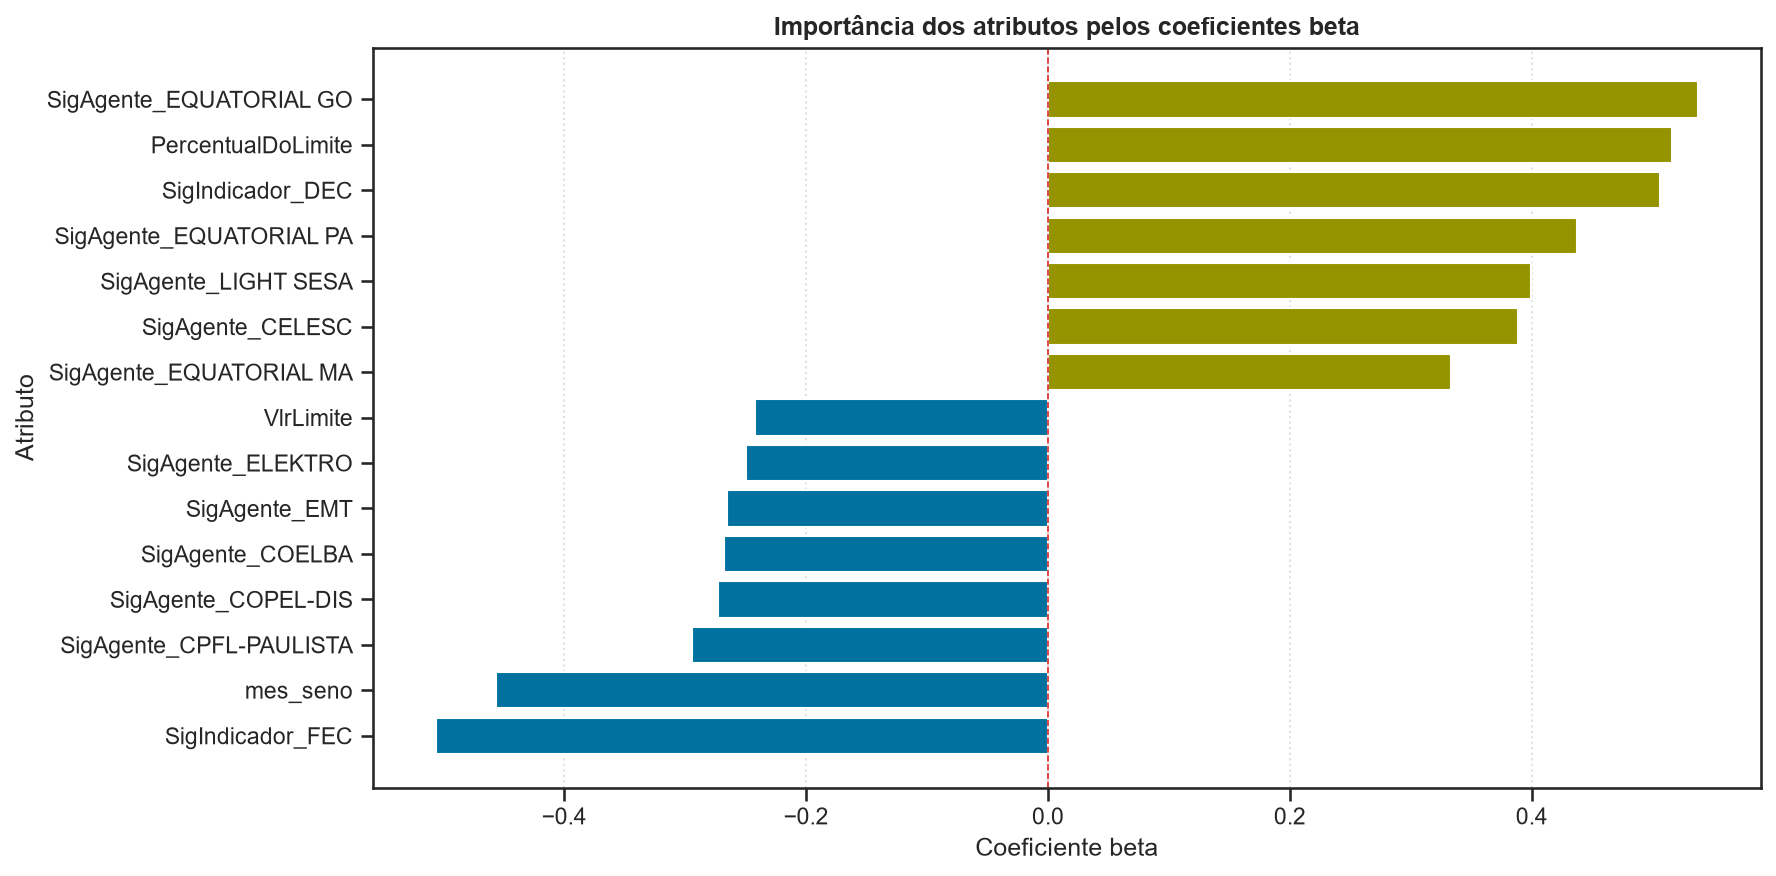


Gráfico salvo com sucesso em: ..\reports\figures\n06_feature_importance.png


In [28]:
# Visualização da importância das features

full_image_path = FIGURE_FEATURE_IMPORTANCE
relative_image_path = os.path.relpath(full_image_path)

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

bar_colors = [
    colors[0] if coeficient > 0 else colors[1]
    for coeficient in top_features["Coeficiente"]
]

ax.barh(
    top_features["Atributo"],
    top_features["Coeficiente"],
    color=bar_colors,
)

ax.axvline(
    0,
    color=additional_colors[3],
    linestyle="--",
    linewidth=0.8,
)

ax.set_title(
    "Importância dos atributos pelos coeficientes beta",
    fontweight="bold",
)

ax.set_xlabel("Coeficiente beta")
ax.set_ylabel("Atributo")
ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("\nGráfico salvo com sucesso em: " f"{relative_image_path}")

- Entre os coeficientes positivos de maior magnitude, `SigAgente_EQUATORIAL GO` apresenta o maior valor, seguido por `PercentualDoLimite` e `SigIndicador_DEC`. As variáveis numéricas indicam associações aprendidas pelo modelo com a probabilidade de transgressão, mas não devem ser interpretadas como relações causais isoladas.

- `SigIndicador_FEC` apresenta o maior impacto absoluto negativo entre os atributos selecionados. O sinal do coeficiente representa a associação condicional estimada pelo modelo, considerando as demais variáveis e o pré-processamento aplicado.

---

## 10. Distribuição de scores de risco

Esta seção analisa a distribuição dos scores de risco gerados pelo modelo com uma comparação entre as classes reais com e sem transgressão. Também é apresentada a segmentação dos registros em faixas operacionais de risco (baixo, médio, alto e crítico) para apoiar a priorização das ações de monitoramento e intervenção.

### 10.1. Gráfico de distribuição dos scores de risco por classe real

O gráfico abaixo representa a distribuição dos scores de risco gerados pelo modelo, separando as observações entre casos com e sem transgressão real. A linha tracejada representa o limiar operacional utilizado.

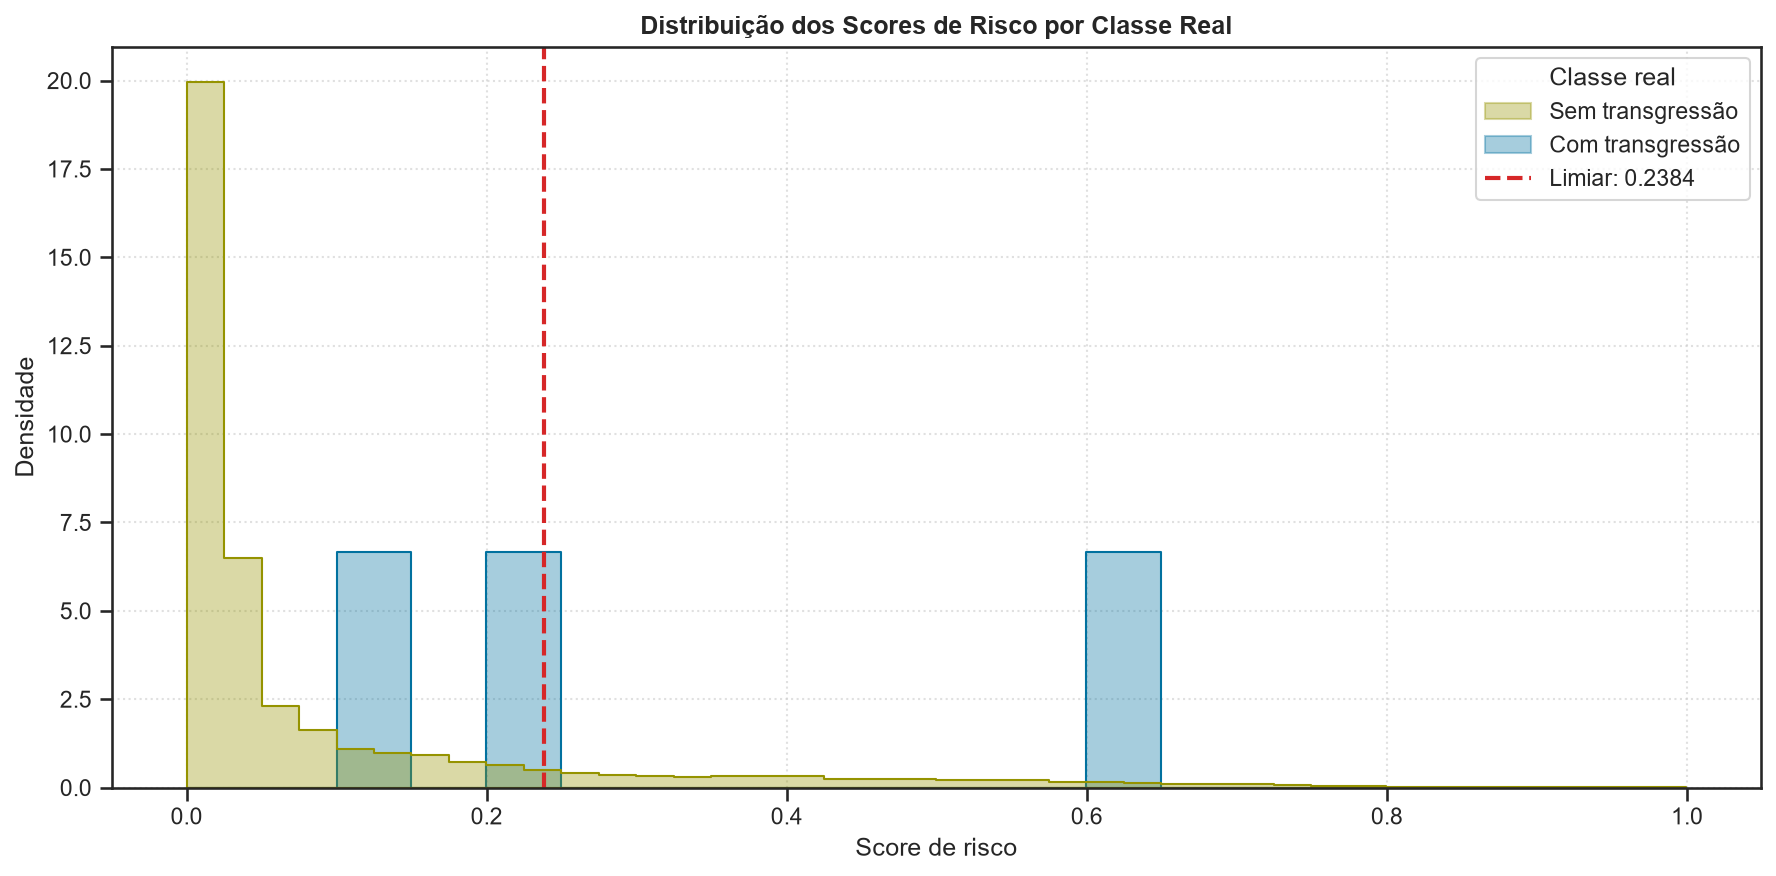


Gráfico salvo com sucesso em: ..\reports\figures\n06_risk_score_distribution.png


In [29]:
# Gráfico de distribuição do score de risco por classe real

full_image_path = FIGURE_RISK_SCORE_DISTRIBUTION
relative_image_path = os.path.relpath(full_image_path)

score_distribution = pd.DataFrame(
    {
        "score_risco": np.asarray(y_score, dtype=float),
        "classe_real": np.asarray(y_test).astype("int8"),
    }
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    dpi=150,
)

sns.histplot(
    data=score_distribution,
    x="score_risco",
    hue="classe_real",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.35,
    palette={
        0: colors[0],
        1: colors[1],
    },
    hue_order=[0, 1],
    ax=ax,
)

ax.axvline(
    threshold,
    color=additional_colors[3],
    linestyle="--",
    linewidth=2,
)

ax.set_title(
    "Distribuição dos Scores de Risco por Classe Real",
    fontweight="bold",
)

ax.set_xlabel("Score de risco")
ax.set_ylabel("Densidade")
ax.grid(True, linestyle=":", alpha=0.6)


legend_handles = [
    Patch(
        facecolor=colors[0],
        edgecolor=colors[0],
        alpha=0.35,
        label="Sem transgressão",
    ),
    Patch(
        facecolor=colors[1],
        edgecolor=colors[1],
        alpha=0.35,
        label="Com transgressão",
    ),
    Line2D(
        [0],
        [0],
        color=additional_colors[3],
        linestyle="--",
        linewidth=2,
        label=f"Limiar: {threshold:.4f}",
    ),
]

ax.legend(
    handles=legend_handles,
    title="Classe real",
)

fig.tight_layout()

fig.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"\nGráfico salvo com sucesso em: {relative_image_path}")

O histograma demonstra que a massa esmagadora de conjuntos sem problemas tem probabilidade quase nula (<0,05). Em contrapartida, os casos reais com falha distribuem-se em patamares elevados validando o limiar como um ponto de equilíbrio.

### 10.2. Distribuição do score por faixa operacional de risco

In [30]:
# Distribuição do score por faixas operacionais de risco

full_table_path = TABLE_RISK_SCORE_DISTRIBUTION
relative_table_path = os.path.relpath(full_table_path)

# 1. Definição das faixas operacionais de risco
bins = [-np.inf, 0.20, 0.50, 0.80, np.inf]

labels = [
    "1. Baixo (<20%)",
    "2. Médio (20-50%)",
    "3. Alto (50-80%)",
    "4. Crítico (≥80%)",
]

df_test_scored = X_test.copy().reset_index(drop=True)

df_test_scored["Score_Risco"] = np.asarray(y_score)
df_test_scored["Real"] = np.asarray(y_test).astype("int8")

df_test_scored["Faixa_Risco"] = pd.cut(
    df_test_scored["Score_Risco"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

ranges_summary = (
    df_test_scored.groupby("Faixa_Risco", observed=False)
    .agg(
        Total_Conjuntos=("Score_Risco", "count"),
        Transgressoes_Reais=("Real", "sum"),
        Score_Medio=("Score_Risco", "mean"),
    )
    .reindex(labels)
    .reset_index()
)

ranges_summary["% da Rede"] = ranges_summary["Total_Conjuntos"] / len(df_test_scored)

ranges_summary["Taxa_Transgressao"] = np.where(
    ranges_summary["Total_Conjuntos"] > 0,
    ranges_summary["Transgressoes_Reais"] / ranges_summary["Total_Conjuntos"],
    0,
)

acoes = {
    "1. Baixo (<20%)": "Operação Normal",
    "2. Médio (20-50%)": "Monitorização Remota",
    "3. Alto (50-80%)": "Alerta e Inspeção Preventiva",
    "4. Crítico (≥80%)": "Vistoria e Intervenção Imediata",
}

ranges_summary["Diretriz de Ação"] = (
    ranges_summary["Faixa_Risco"].astype(str).map(acoes)
)

display(
    ranges_summary.style.format(
        {
            "Total_Conjuntos": "{:,.0f}",
            "Transgressoes_Reais": "{:,.0f}",
            "% da Rede": "{:.2%}",
            "Score_Medio": "{:.2%}",
            "Taxa_Transgressao": "{:.4%}",
        },
        na_rep="—",
    )
)

ranges_summary.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,Faixa_Risco,Total_Conjuntos,Transgressoes_Reais,Score_Medio,% da Rede,Taxa_Transgressao,Diretriz de Ação
0,1. Baixo (<20%),"58,872",2,3.59%,85.29%,0.0034%,Operação Normal
1,2. Médio (20-50%),"7,244",2,32.64%,10.49%,0.0276%,Monitorização Remota
2,3. Alto (50-80%),"2,746",2,61.12%,3.98%,0.0728%,Alerta e Inspeção Preventiva
3,4. Crítico (≥80%),164,0,86.44%,0.24%,0.0000%,Vistoria e Intervenção Imediata



Tabela salva com sucesso em: ..\docs\metadata\n06_score_distribution.csv


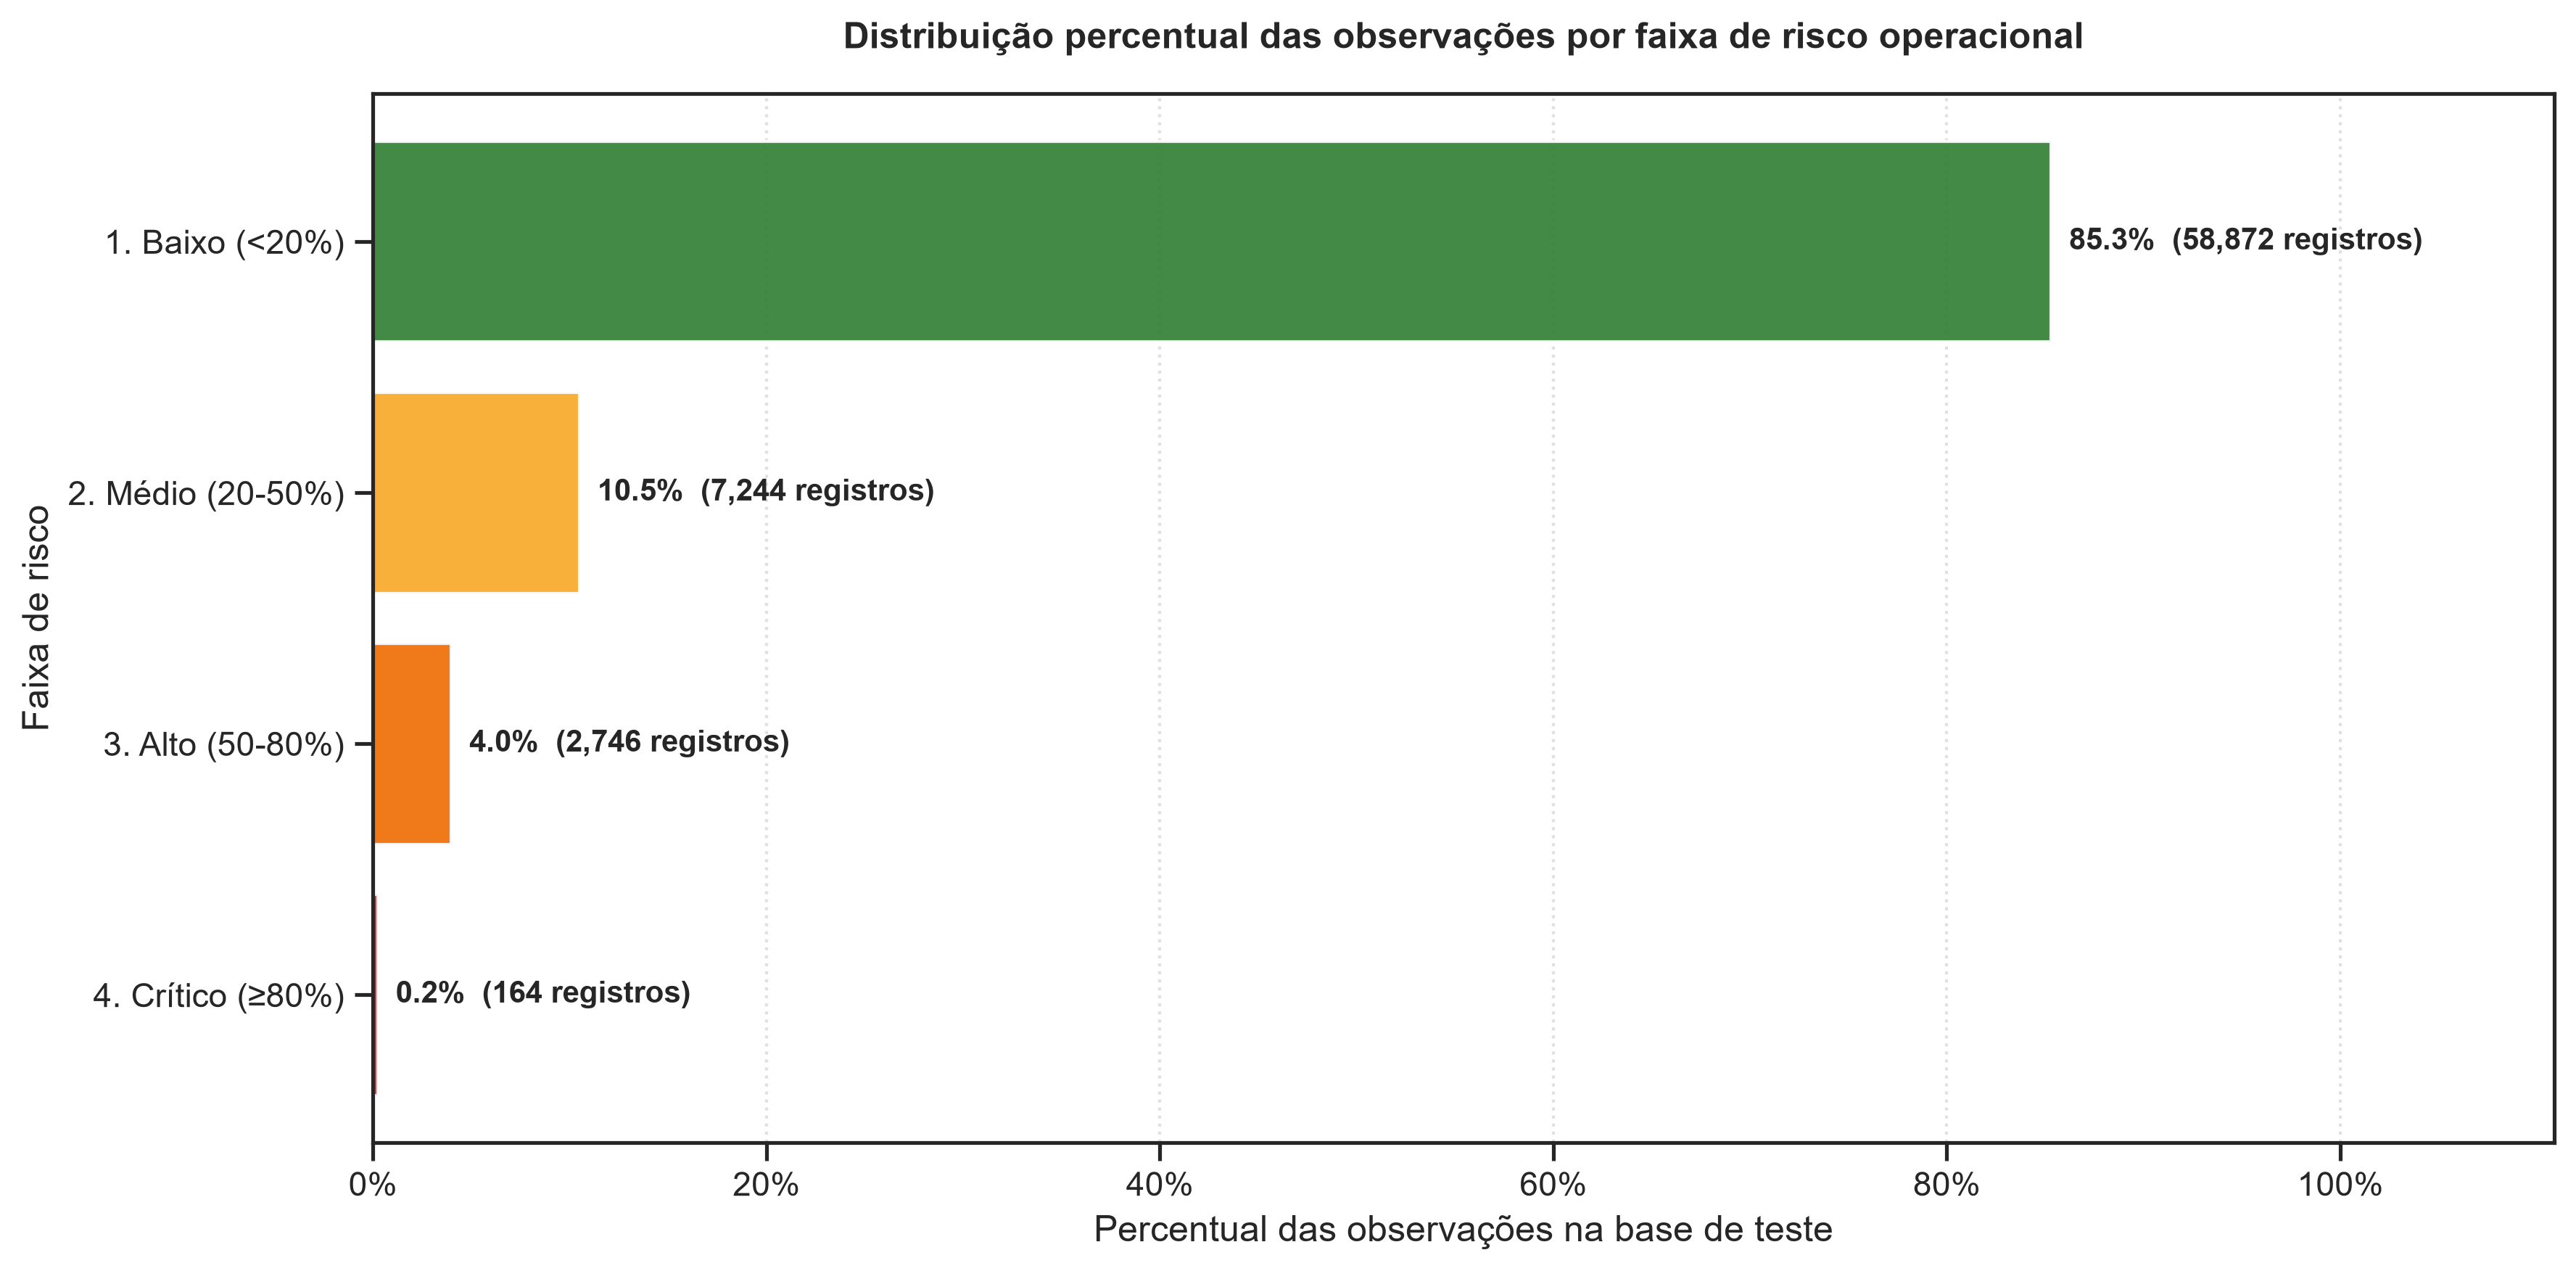


Gráfico salvo com sucesso em: ..\reports\figures\n06_risk_score_ranges.png


In [31]:
# Gráfico de distribuição das faixas operacionais de risco

full_image_path = FIGURE_RISK_SCORE_RANGES
relative_image_path = os.path.relpath(full_image_path)

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

range_colors = [
    additional_colors[0],
    additional_colors[1],
    additional_colors[2],
    additional_colors[3],
]
range_percentages = ranges_summary["% da Rede"].to_numpy()
range_counts = ranges_summary["Total_Conjuntos"].to_numpy()
y_positions = np.arange(len(labels))

bars = ax.barh(
    y_positions,
    range_percentages,
    color=range_colors,
    alpha=0.9,
)

for bar, percentage, count in zip(bars, range_percentages, range_counts):
    ax.annotate(
        f"{percentage:.1%}  ({int(count):,} registros)",
        (
            percentage,
            bar.get_y() + bar.get_height() / 2,
        ),
        ha="left",
        va="center",
        xytext=(6, 0),
        textcoords="offset points",
        fontweight="bold",
        fontsize=10,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, max(range_percentages) * 1.3)
ax.set_title(
    "Distribuição percentual das observações por faixa de risco operacional",
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Percentual das observações na base de teste")
ax.set_ylabel("Faixa de risco")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{value:.0%}"))
ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(
    full_image_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("\nGráfico salvo com sucesso em: " f"{relative_image_path}")

- A segmentação em quatro níveis organiza o volume de alertas por prioridade. Os percentuais e as quantidades de registros apresentados na tabela acima são calculados diretamente sobre o conjunto de teste de 2025 e devem ser tratados como um retrato da distribuição atual dos scores, não como uma proporção fixa da rede ao longo do tempo.

- Considerando as quatro faixas de risco operacional, a concentração de mais de **85%** dos registros no nível baixo face ao volume reduzido de registros no nível crítico (**0,2%**) tem o potencial de viabilizar a auditoria e a inspeção humana desses conjuntos alertados.

---

## 11. Limitações do modelo

* O modelo baseia-se em histórico regulatório, métricas defasadas (*lags*) e tendências de degradação da rede. Com isso, torna-se incapaz de antecipar transgressões causadas por causas pontuais e/ou acidentais, tais como tempestades atípicas ou queimadas, o que pode ajudar a explicar os casos de falsos negativos.

* O número reduzido de transgressões nas partições temporais torna as métricas sensíveis a pequenas variações nos dados. Portanto, os resultados devem ser interpretados como evidências experimentais, e não como garantia de desempenho futuro.

* A granularidade mensal dos dados regulatórios da ANEEL mascara variações pontuais. Interrupções severas concentradas em poucos dias consecutivos não são capturadas como tendência prévia se o início do mês apresentou operação estável.

* Devido ao severo desbalanceamento de classes, conjuntos com histórico de estresse operacional contínuo recebem scores intermediários a altos, mesmo quando a distribuidora consegue evitar a transgressão no limite, demandando triagem pelas faixas de risco para que não haja uma sobrecarga de falsos positivos.

---

## 12. Conclusões da avaliação


- O modelo de Regressão Logística apresentou capacidade de generalização no teste cego, mantendo ROC-AUC de **0,8754** e superando o baseline em aproximadamente **7,1 vezes no PR-AUC** (0,000624 contra 0,000087).

- O estimador é interpretável por meio de coeficientes lineares. Entre os atributos selecionados, `SigAgente_EQUATORIAL GO`, `PercentualDoLimite` e `SigIndicador_DEC` estão entre as associações positivas de maior magnitude, enquanto `SigIndicador_FEC` apresenta forte associação negativa.

- O modelo apresentou capacidade de diferenciar observações com e sem transgressão, embora exista sobreposição entre as distribuições de scores. Essa sobreposição explica a ocorrência de falsos positivos e falsos negativos sob o limiar operacional calibrado em **0,2384**.

- A análise residual mostra forte concentração de observações com scores próximos de zero, especialmente entre os casos sem transgressão. Os resíduos negativos mais expressivos concentram-se nos falsos positivos, que representam observações classificadas como alertas apesar de não apresentarem transgressão no conjunto de teste.

- A estratificação em quatro faixas organiza a malha por prioridade operacional. Os percentuais e as quantidades devem ser consultados na tabela gerada para o conjunto de teste, enquanto o pipeline automatizado via `src/data/run_inference.py` cria tabela de inferência no formato Parquet que pode ser integrado no Star Schema do Power BI.